# Presentation figures

This notebook is the place to restyle the rolling ETAS vs FINE figures and export them again.

Edit **Style** (colors, fonts, sizes, colormaps). Every figure below reads that dict. Re-run from the style cell downward after a change.

Analysis stays on the cached horizon tables (`scores.csv`, realization counts, event catalogs, intensity grids). The last section rebuilds spatial and magnitude statistics only when its cache is missing.

Each panel is its own figure, saved as PNG and SVG under `outputs/presentation_figures/`. Horizon-specific figures are written for every horizon in `HORIZONS`.

Across-horizon comparisons (one figure, x-axis is forecast length) stay as single plots. The CSEP/Molchan and binary paired-T curves recompute catalog tests; leave `COMPUTE_HEAVY_ACROSS` off unless you want those rebuilt.


In [1]:
from __future__ import annotations

%matplotlib inline

import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import io

from IPython.display import Image, Markdown, display

# ---------------------------------------------------------------------------
# Style — change these, then re-run the notebook. Do not hard-code colors below.
# ---------------------------------------------------------------------------
STYLE = {
    "font": {
        "family": "DejaVu Sans",
        "size": 11,
        "title": 12,
        "label": 11,
        "tick": 10,
        "legend": 9,
    },
    "colors": {
        "observed": "#1a1a1a",
        "expected": "#111111",
        "poisson": "#111111",
        "nbd": "#737373",
        "reference": "#808080",
        "grid": "#d0d0d0",
        "pass": "#2ca02c",
        "fail": "#d62728",
        "secondary": {
            "pass": "#1f4e79",
            "fail": "#c47b00",
        },
        "magnitude": "#6e2a2a",
        "methods": {
            "etas": "#2E8B57",
            "FINE": "#7B68EE",
        },
    },
    "cmaps": {
        "discrepancy": "coolwarm",
        "coverage": "Greys",
        "rate": "viridis",
        "spatial_observed": "Greys",
        "spatial_forecast": "viridis",
    },
    "labels": {"etas": "ETAS", "FINE": "FINE"},
    "markers": {"etas": "o", "FINE": "s"},
    "figsize": {
        "metric": (7.2, 4.2),
        "wide": (11.0, 4.4),
        "wide_short": (11.0, 3.6),
        "square": (6.4, 6.4),
        "hist": (5.2, 3.6),
        "map": (6.4, 5.6),
        "number_rows": (7.2, 3.4),
    },
    "line_width": 1.4,
    "marker_size": 4.5,
    "scatter_size": 70,
    "coverage_marker": 28,
    "marker_area_base": 14.0,
    "marker_area_scale": 5.0,
    "count_floor": 0.8,
    "magnitude_size_scale": 6.0,
    "magnitude_size_shift": 2.0,
    "epicenter_scale": 3.5,
    "epicenter_growth": 2.6,
    "spatial_bins": 60,
    "fill_alpha": 0.22,
    "realization_alpha": 0.28,
    "legend_frameon": False,
    "spines_top_right": False,
    "axes_linewidth": 0.8,
    "display_dpi": 110,
    "save_dpi": 300,
    "save_png": False,
    "save_pdf": False,
    "save_svg": False,
    "overwrite": True,
}

# Which forecast lengths to draw. None = every cached horizon.
HORIZONS: list[float] | None = None
METHODS = ["etas", "FINE"]
# Middle window when None. Set an integer to pin the realization histogram.
COUNT_HIST_STEP: int | None = None
EVENT_RATE_BIN_DAYS = 30.0
# Rebuild spatial / magnitude tables even if presentation_tables/ already exists.
REBUILD_CATALOG_TABLES = False
# PyCSEP catalog tests and the binary paired T-test across horizons.
COMPUTE_HEAVY_ACROSS = False


def find_repo_root() -> Path:
    for start in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (start / "runnable_code" / "presentation_figures.py").is_file():
            return start
    raise FileNotFoundError("Open this notebook from the etas checkout.")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(REPO_ROOT / "runnable_code") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "runnable_code"))

import importlib
import presentation_figures as figures
importlib.reload(figures)
figures.configure(STYLE)
FIGURE_DIR = REPO_ROOT / "outputs" / "presentation_figures"


def save_figure(figure, filename, directory, dpi=300, save_png=True, save_pdf=True, save_svg=True, overwrite=False):
    """Save a figure as PNG, PDF, and/or SVG.

    Parameters match the paper-figure helper: filename without extension,
    dpi, per-format switches, and overwrite.
    """
    if not os.path.exists(directory):
        os.makedirs(directory)
    if overwrite or not os.path.exists(os.path.join(directory, f"{filename}.png")):
        if save_png:
            figure.savefig(os.path.join(directory, f"{filename}.png"), dpi=dpi, format="png")
    if overwrite or not os.path.exists(os.path.join(directory, f"{filename}.pdf")):
        if save_pdf:
            figure.savefig(os.path.join(directory, f"{filename}.pdf"), dpi=dpi, format="pdf")
    if overwrite or not os.path.exists(os.path.join(directory, f"{filename}.svg")):
        if save_svg:
            figure.savefig(os.path.join(directory, f"{filename}.svg"), dpi=dpi, format="svg")


def _horizon_days_from_folder(folder: tuple[str, ...]) -> float | None:
    """``horizon_7d`` / ``horizon_0p5d`` name one forecast length. Other folders do not."""
    if not folder:
        return None
    name = str(folder[0])
    if not (name.startswith("horizon_") and name.endswith("d")):
        return None
    return float(name[len("horizon_"):-1].replace("p", "."))


def _title_names_horizon(title: str, days: float) -> bool:
    text = f"{days:g}"
    return f"{text} d" in title or f"{text}-day" in title


def _with_horizon_title(title: str, days: float) -> str:
    if not title or _title_names_horizon(title, days):
        return title
    suffix = f" — T = {days:g} d"
    if "\n" in title:
        head, tail = title.split("\n", 1)
        return f"{head}{suffix}\n{tail}"
    return f"{title}{suffix}"


def stamp_single_horizon_figure(fig, days: float):
    """Put the forecast length on every title of a one-horizon panel."""
    suptitle = fig._suptitle.get_text() if fig._suptitle is not None else ""
    if suptitle:
        fig.suptitle(_with_horizon_title(suptitle, days))
    for ax in fig.axes:
        title = ax.get_title()
        if title:
            ax.set_title(_with_horizon_title(title, days))
    return fig


def export(fig, filename: str, *folder: str) -> None:
    """Save one panel and show it. ``folder`` is relative to FIGURE_DIR."""
    if fig is None:
        display(Markdown(f"*Skipped `{filename}`.*"))
        return
    days = _horizon_days_from_folder(folder)
    if days is not None:
        stamp_single_horizon_figure(fig, days)
    directory = FIGURE_DIR.joinpath(*folder) if folder else FIGURE_DIR
    save_figure(
        fig,
        filename,
        directory,
        dpi=STYLE["save_dpi"],
        save_png=STYLE["save_png"],
        save_pdf=STYLE["save_pdf"],
        save_svg=STYLE["save_svg"],
        overwrite=STYLE["overwrite"],
    )
    # display(fig) then plt.close(fig) is captured as "..." in this notebook.
    # Write the PNG first, then show those bytes.
    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", dpi=STYLE["display_dpi"], bbox_inches="tight")
    plt.close(fig)
    display(Image(data=buffer.getvalue()))


def horizon_tag(days: float) -> str:
    text = f"{days:g}".replace(".", "p")
    return f"horizon_{text}d"


## Load cached comparisons

Scores and summaries are read from the two pre-Ridgecrest output roots. No forecasts are recomputed here.


In [2]:
import etas.bayona_evaluations as bayona_evaluations
import etas.horizon_comparison as horizon_comparison
import etas.rolling_analysis as rolling_analysis

EXPERIMENTS = [
    {
        "output_root": REPO_ROOT / "outputs/rolling_continuation_hauksson_pre_ridgecrest_short",
        "horizon_days": [0.5, 1.0],
    },
    {
        "output_root": REPO_ROOT / "outputs/rolling_continuation_hauksson_pre_ridgecrest",
        "horizon_days": [7.0, 60.0, 300.0],
    },
]


def _horizon_dir(output_root: Path, days: float) -> Path:
    return rolling_analysis.horizon_directory(output_root, days)


specs = []
for experiment in EXPERIMENTS:
    root = experiment["output_root"]
    if not root.is_dir():
        continue
    for days in experiment["horizon_days"]:
        horizon_dir = _horizon_dir(root, float(days))
        cache = horizon_dir / "analysis_cache"
        if (cache / "scores.csv").is_file():
            specs.append({"horizon_days": float(days), "output_root": root, "horizon_dir": horizon_dir})

if HORIZONS is not None:
    chosen = {float(days) for days in HORIZONS}
    specs = [item for item in specs if item["horizon_days"] in chosen]
specs = sorted(specs, key=lambda item: item["horizon_days"])
HORIZON_LIST = [item["horizon_days"] for item in specs]

score_frames = []
summary_frames = []
for experiment in EXPERIMENTS:
    comparison_dir = experiment["output_root"] / "horizon_comparison"
    if (comparison_dir / "scores.csv").is_file():
        score_frames.append(pd.read_csv(comparison_dir / "scores.csv"))
    if (comparison_dir / "summary.csv").is_file():
        summary_frames.append(pd.read_csv(comparison_dir / "summary.csv"))

scores_all = pd.concat(score_frames, ignore_index=True) if score_frames else pd.DataFrame()
summary = pd.concat(summary_frames, ignore_index=True) if summary_frames else pd.DataFrame()
if len(scores_all):
    for column in ("forecast_start", "forecast_end"):
        if column in scores_all.columns:
            scores_all[column] = pd.to_datetime(scores_all[column], format="mixed")
    if HORIZONS is not None:
        mask = np.isin(scores_all["horizon_days"].to_numpy(dtype=float), HORIZON_LIST)
        scores_all = scores_all.loc[mask].copy()
    if len(summary):
        mask = np.isin(summary["horizon_days"].to_numpy(dtype=float), HORIZON_LIST)
        summary = summary.loc[mask].copy()

display(Markdown(
    "**Horizons:** "
    + ", ".join(f"{days:g} d" for days in HORIZON_LIST)
    + f"  \n**Figure directory:** `{FIGURE_DIR}`"
))


**Horizons:** 0.5 d, 1 d, 7 d, 60 d, 300 d  
**Figure directory:** `/home/neriberman/Repos/etas/outputs/presentation_figures`

## Across horizons

One curve per method. The x-axis is the forecast length, so these are not repeated per horizon.


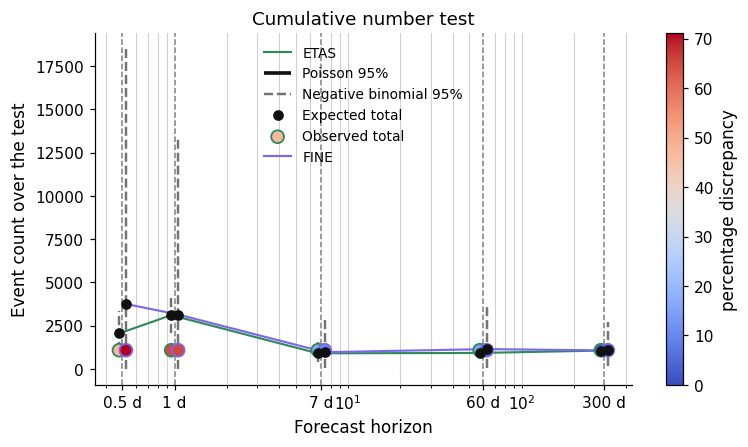

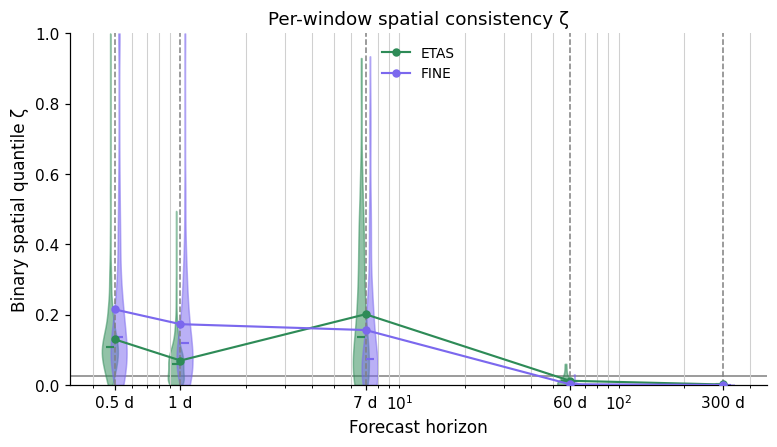

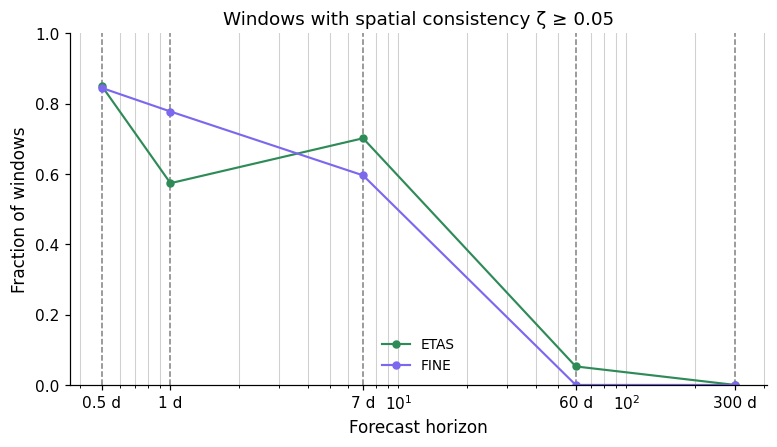

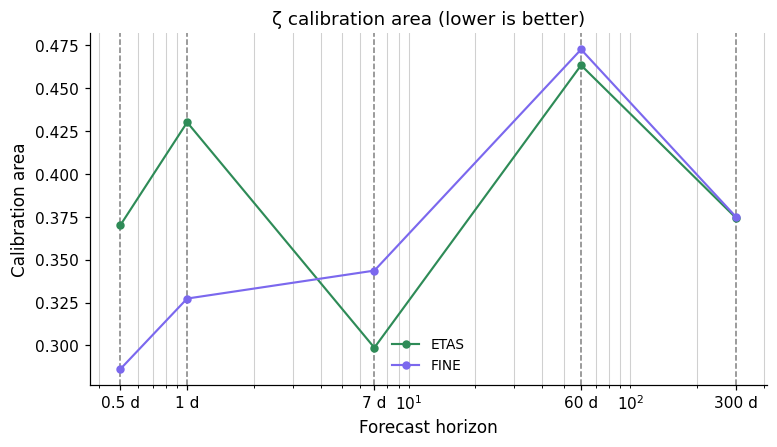

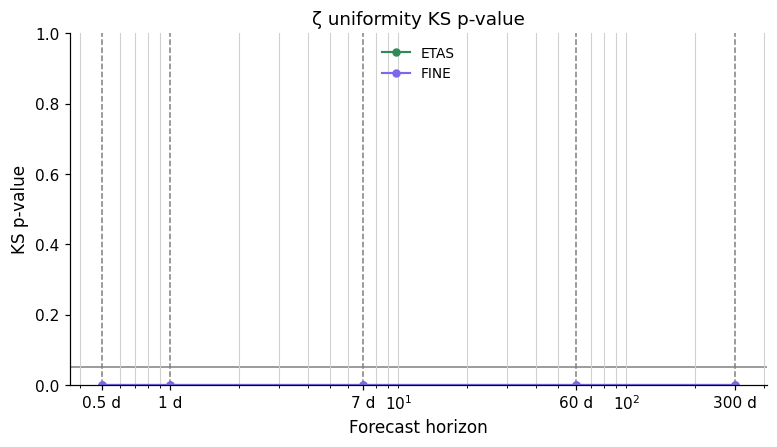

...

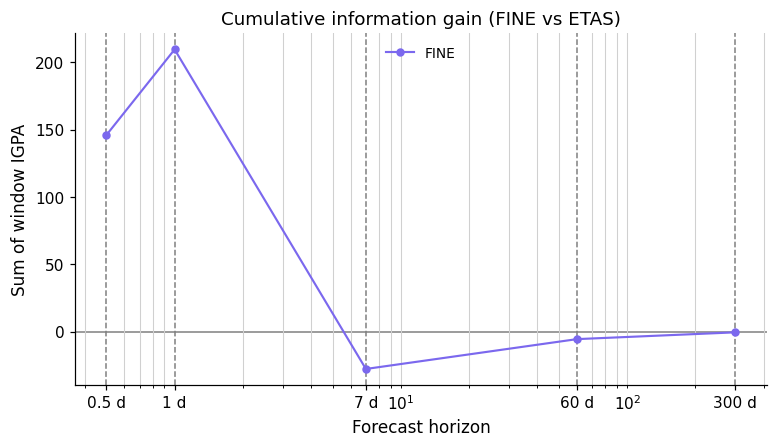

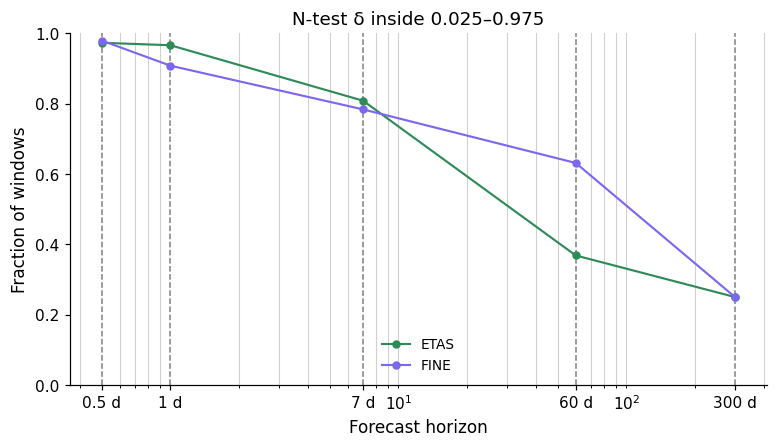

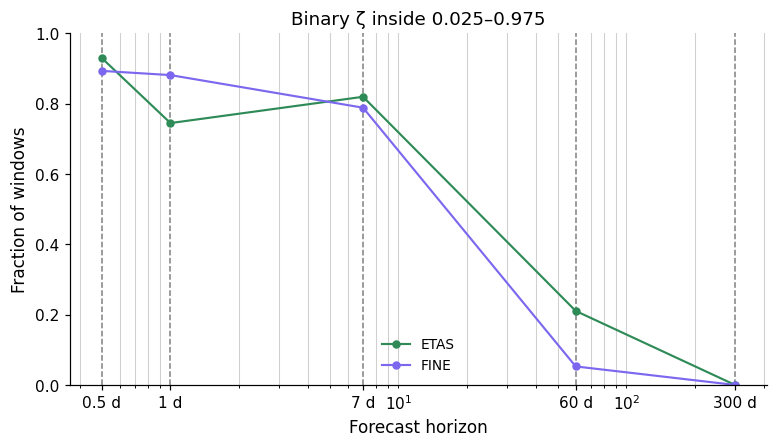

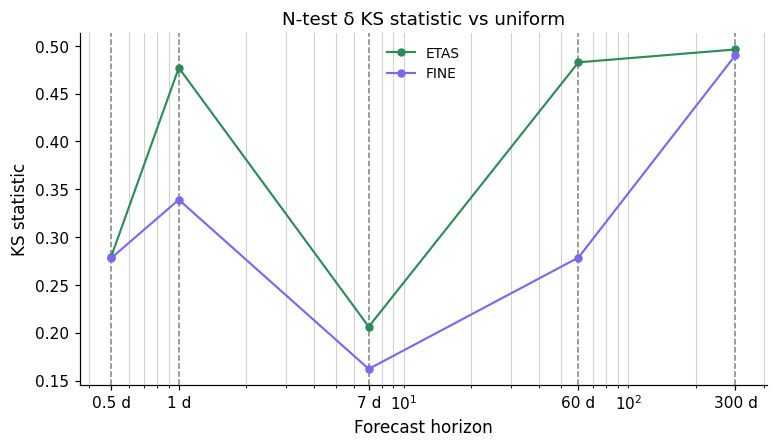

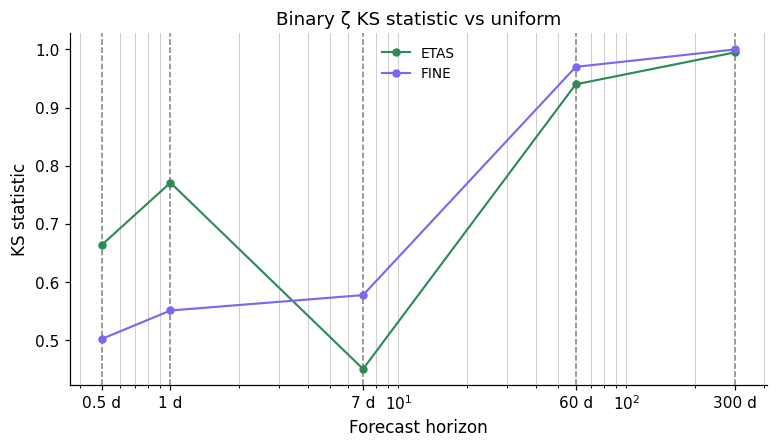

In [3]:
from scipy import stats as scipy_stats

plot_summary = summary.copy()
if len(plot_summary):
    plot_summary["mean_n_forecast"] = plot_summary["total_forecast"] / plot_summary["n_windows"]
    plot_summary["mean_n_observed"] = plot_summary["total_observed"] / plot_summary["n_windows"]

calibration_rows = []
igpa_rows = []
if len(scores_all):
    for (days, method), group in scores_all.groupby(["horizon_days", "method"], sort=False):
        zeta = pd.to_numeric(group["zeta"], errors="coerce").to_numpy(dtype=float)
        zeta = zeta[np.isfinite(zeta)]
        if zeta.size:
            calibration = bayona_evaluations.quantile_calibration(zeta)
            calibration_rows.append({
                "horizon_days": float(days),
                "method": method,
                "zeta_calibration_area": float(calibration["area"]),
                "zeta_ks_pvalue": float(calibration["ks_pvalue"]),
            })
        if "IGPA" in group.columns:
            igpa = pd.to_numeric(group["IGPA"], errors="coerce")
            if igpa.notna().any():
                igpa_rows.append({
                    "horizon_days": float(days),
                    "method": method,
                    "cumulative_igpa": float(igpa.sum()),
                })
if calibration_rows:
    plot_summary = plot_summary.merge(pd.DataFrame(calibration_rows), on=["horizon_days", "method"], how="left")
if igpa_rows:
    plot_summary = plot_summary.merge(pd.DataFrame(igpa_rows), on=["horizon_days", "method"], how="left")


def _band_fraction(values) -> float:
    finite = np.asarray(values, dtype=float)
    finite = finite[np.isfinite(finite)]
    if finite.size == 0:
        return float("nan")
    return float(((finite >= 0.025) & (finite <= 0.975)).mean())


def _ks_uniform(values) -> float:
    finite = np.asarray(values, dtype=float)
    finite = finite[np.isfinite(finite)]
    if finite.size == 0:
        return float("nan")
    return float(scipy_stats.kstest(finite, "uniform").statistic)


band_rows = []
if len(scores_all):
    for (days, method), group in scores_all.groupby(["horizon_days", "method"], sort=False):
        band_rows.append({
            "horizon_days": float(days),
            "method": method,
            "fraction_delta_inside_band": _band_fraction(group["poisson_delta2"]),
            "fraction_binary_zeta_inside_band": _band_fraction(group["zeta"]),
            "ks_delta": _ks_uniform(group["poisson_delta2"]),
            "ks_binary_zeta": _ks_uniform(group["zeta"]),
        })
band_fast = pd.DataFrame(band_rows)

number_rows = []
for spec in specs:
    store = rolling_analysis.load_analysis(spec["horizon_dir"])
    horizon_scores = store.scores
    if horizon_scores.empty:
        continue
    observed_total = float(horizon_scores.drop_duplicates("step_index")["n_observed"].sum())
    for method in METHODS:
        group = horizon_scores.loc[horizon_scores["method"] == method]
        if group.empty:
            continue
        n_forecast = float(group["n_forecast"].sum())
        poisson_low, poisson_high = bayona_evaluations.fmd_poisson_intervals(np.array([n_forecast]))
        sizes = np.array([len(store.event_frame(method, int(seed))) for seed in store.seeds], dtype=float)
        variance = float(np.var(sizes, ddof=1)) if sizes.size >= 2 else float("nan")
        nbd = bayona_evaluations.negative_binomial_interval(n_forecast, variance)
        number_rows.append({
            "horizon_days": spec["horizon_days"],
            "method": method,
            "label": figures.method_label(method),
            "n_forecast": n_forecast,
            "n_observed": observed_total,
            "delta_percent": bayona_evaluations.count_discrepancy(n_forecast, observed_total),
            "poisson_low": float(poisson_low[0]),
            "poisson_high": float(poisson_high[0]),
            "nbd_low": np.nan if nbd is None else float(nbd[0]),
            "nbd_high": np.nan if nbd is None else float(nbd[1]),
        })
cumulative_number = pd.DataFrame(number_rows)

if len(cumulative_number):
    export(
        figures.fig_cumulative_number_vs_horizon(cumulative_number, METHODS),
        "cumulative_number_test",
        "across_horizons",
    )
if len(scores_all) and "zeta" in scores_all.columns:
    export(
        figures.fig_zeta_violin(scores_all, HORIZON_LIST, METHODS),
        "per_window_spatial_consistency_zeta",
        "across_horizons",
    )

metric_specs = [
    ("fraction_zeta_ge_0.05", "Windows with spatial consistency ζ ≥ 0.05", "Fraction of windows", (0.0, 1.0), None, METHODS),
    ("zeta_calibration_area", "ζ calibration area (lower is better)", "Calibration area", None, None, METHODS),
    ("zeta_ks_pvalue", "ζ uniformity KS p-value", "KS p-value", (0.0, 1.0), 0.05, METHODS),
    ("mean_delta_percent", "Mean per-window count discrepancy", "Discrepancy (%)", None, None, METHODS),
    ("mean_n_forecast", "Mean expected events per window", "Events per window", None, None, METHODS),
    ("fraction_poisson_consistent_95", "Windows passing Poisson 95% number test", "Fraction of windows", (0.0, 1.0), None, METHODS),
    ("fraction_nbd_consistent_95", "Windows passing NBD 95% number test", "Fraction of windows", (0.0, 1.0), None, METHODS),
    ("fraction_binary_cl_consistent_95", "Windows passing binary conditional-likelihood 95% test", "Fraction of windows", (0.0, 1.0), None, METHODS),
    ("mean_igpa", "Mean information gain per alarm (FINE vs ETAS)", "Mean IGPA", None, 0.0, ["FINE"]),
    ("cumulative_igpa", "Cumulative information gain (FINE vs ETAS)", "Sum of window IGPA", None, 0.0, ["FINE"]),
]
for metric, title, ylabel, ylim, hline, methods_to_plot in metric_specs:
    if metric not in plot_summary.columns or plot_summary[metric].isna().all():
        display(Markdown(f"*Skipped `{title}`.*"))
        continue
    export(
        figures.fig_metric_vs_horizon(
            plot_summary, metric, HORIZON_LIST,
            title=title, ylabel=ylabel, methods=methods_to_plot, ylim=ylim, hline=hline,
        ),
        metric,
        "across_horizons",
    )

fast_band_specs = [
    ("fraction_delta_inside_band", "N-test δ inside 0.025–0.975", "Fraction of windows", (0.0, 1.0)),
    ("fraction_binary_zeta_inside_band", "Binary ζ inside 0.025–0.975", "Fraction of windows", (0.0, 1.0)),
    ("ks_delta", "N-test δ KS statistic vs uniform", "KS statistic", None),
    ("ks_binary_zeta", "Binary ζ KS statistic vs uniform", "KS statistic", None),
]
for metric, title, ylabel, ylim in fast_band_specs:
    if band_fast.empty or metric not in band_fast.columns:
        continue
    export(
        figures.fig_metric_vs_horizon(
            band_fast, metric, HORIZON_LIST,
            title=title, ylabel=ylabel, methods=METHODS, ylim=ylim,
        ),
        metric,
        "across_horizons",
    )


## Heavy across-horizon tests

These two families call PyCSEP on the concatenated catalogs. They are off until `COMPUTE_HEAVY_ACROSS` is true. Results are cached as CSV so later design passes only redraw.


In [4]:
heavy_dir = FIGURE_DIR / "across_horizons"
paired_path = heavy_dir / "binary_paired_t.csv"
csep_path = heavy_dir / "csep_molchan.csv"

if COMPUTE_HEAVY_ACROSS:
    import etas.csep_utils as csep_utils
    from csep.core import binomial_evaluations

    if not hasattr(binomial_evaluations, "np"):
        binomial_evaluations.np = np

    paired_rows = []
    csep_rows = []
    for spec in specs:
        store = rolling_analysis.load_analysis(spec["horizon_dir"])
        days = spec["horizon_days"]
        rates = store.mean_rate_grid()
        windows = store.windows()
        if windows.empty or "FINE" not in rates or "etas" not in rates:
            continue
        region, study_poly, fit = store.forecast_region()
        start = windows["forecast_start"].min().to_pydatetime()
        end = windows["forecast_end"].max().to_pydatetime()
        observed = store.observed_frame().copy()
        if "time" not in observed.columns and "time_days" in observed.columns:
            observed["time"] = figures.ORIGIN + pd.to_timedelta(observed["time_days"], unit="D")
        observed = csep_utils.filter_to_csep_region(
            observed, region=region, m_ref=float(fit["m_ref"]), study_poly=study_poly,
        )
        observed_catalog = csep_utils.dataframe_to_csep_catalog(
            observed, catalog_id=int(round(10 * days)), region=region,
        )
        if observed_catalog.event_count >= 2:
            forecast_fine = csep_utils.gridded_forecast_from_rates(
                rates["FINE"], region, start, end, "FINE",
            )
            forecast_etas = csep_utils.gridded_forecast_from_rates(
                rates["etas"], region, start, end, "ETAS",
            )
            result = binomial_evaluations.binary_paired_t_test(
                forecast_fine, forecast_etas, observed_catalog,
            )
            ig_lower, ig_upper = result.test_distribution
            paired_rows.append({
                "horizon_days": days,
                "information_gain": float(result.observed_statistic),
                "ig_lower": float(ig_lower),
                "ig_upper": float(ig_upper),
            })
        print(f"CSEP/Molchan T={days:g} d", flush=True)
        for method in METHODS:
            catalogs = []
            for seed in store.seeds:
                frame = store.event_frame(method, int(seed)).copy()
                frame["time"] = figures.ORIGIN + pd.to_timedelta(frame["time_days"], unit="D")
                catalogs.append(frame)
            forecast = csep_utils.build_catalog_forecast_from_dataframes(
                catalogs,
                name=figures.method_label(method),
                region=region,
                start_time=start,
                end_time=end,
                m_ref=float(fit["m_ref"]),
                study_poly=study_poly,
            )
            scores = csep_utils.run_csep_catalog_tests(
                forecast, observed_catalog, include_l_test=True, l_test_simulations=200, l_test_seed=0,
            )
            csep_utils.pop_csep_sim_arrays(scores)
            try:
                molchan = csep_utils.molchan_from_catalog_forecast(forecast, observed_catalog)
                molchan_auc = float(molchan.area_under_curve)
            except Exception:
                molchan_auc = float("nan")
            csep_rows.append({
                "horizon_days": days,
                "method": method,
                "PL_delta": float(scores["L_delta2"]),
                "N_delta": float(min(scores["N_delta1"], scores["N_delta2"])),
                "N_delta2": float(scores["N_delta2"]),
                "M_delta": float(scores["M_delta2"]),
                "S_delta": float(scores["S_delta2"]),
                "L_delta": float(scores.get("Ltest_gamma", float("nan"))),
                "molchan_auc": molchan_auc,
            })
    heavy_dir.mkdir(parents=True, exist_ok=True)
    pd.DataFrame(paired_rows).to_csv(paired_path, index=False)
    pd.DataFrame(csep_rows).to_csv(csep_path, index=False)

if paired_path.is_file():
    paired = pd.read_csv(paired_path)
    if len(paired):
        export(
            figures.fig_paired_t(paired, HORIZON_LIST, title="Binary paired T-test (FINE vs ETAS)"),
            "binary_paired_t",
            "across_horizons",
        )
else:
    display(Markdown("*Binary paired T-test is cached after `COMPUTE_HEAVY_ACROSS = True`.*"))

if csep_path.is_file():
    csep_table = pd.read_csv(csep_path)
    csep_specs = [
        ("PL_delta", "PL-test δ₂ vs forecast horizon", "PL-test δ₂", 0.025),
        ("N_delta", "N-test min(δ₁, δ₂) vs forecast horizon", "N-test min(δ₁, δ₂)", 0.05),
        ("N_delta2", "N-test δ₂ vs forecast horizon", "N-test δ₂", 0.025),
        ("M_delta", "M-test δ₂ vs forecast horizon", "M-test δ₂", 0.025),
        ("S_delta", "S-test δ₂ vs forecast horizon", "S-test δ₂", 0.025),
        ("L_delta", "Poisson L-test γ vs forecast horizon", "L-test γ", 0.025),
        ("molchan_auc", "Molchan area under miss-rate curve vs forecast horizon", "Area under Molchan curve", 0.5),
    ]
    for metric, title, ylabel, hline in csep_specs:
        if metric not in csep_table.columns or csep_table[metric].isna().all():
            display(Markdown(f"*Skipped `{title}` (column missing in the cache).*"))
            continue
        export(
            figures.fig_metric_vs_horizon(
                csep_table, metric, HORIZON_LIST,
                title=title, ylabel=ylabel, methods=METHODS, ylim=(0.0, 1.0), hline=hline,
            ),
            metric,
            "across_horizons",
        )
else:
    display(Markdown("*CSEP / Molchan curves are cached after `COMPUTE_HEAVY_ACROSS = True`.*"))


*Binary paired T-test is cached after `COMPUTE_HEAVY_ACROSS = True`.*

*CSEP / Molchan curves are cached after `COMPUTE_HEAVY_ACROSS = True`.*

## Each horizon — window counts

The attached walk-forward figures. One file per horizon.


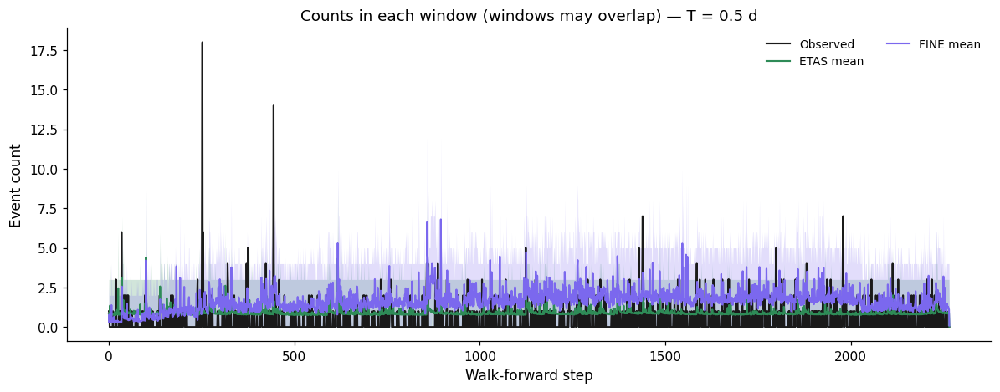

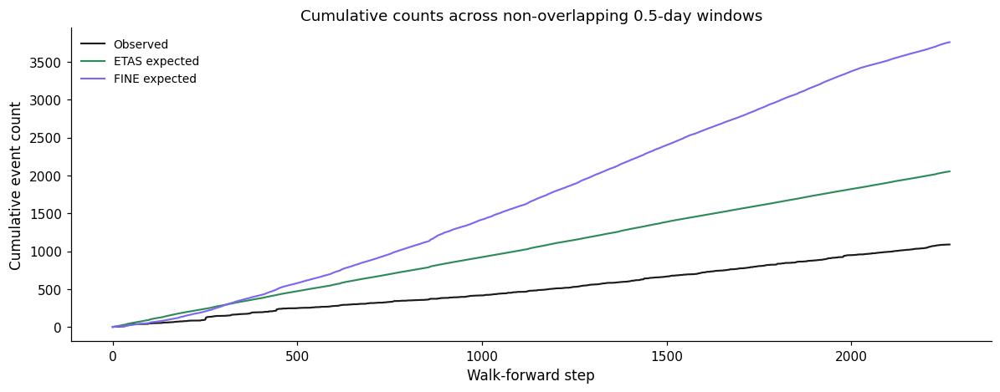

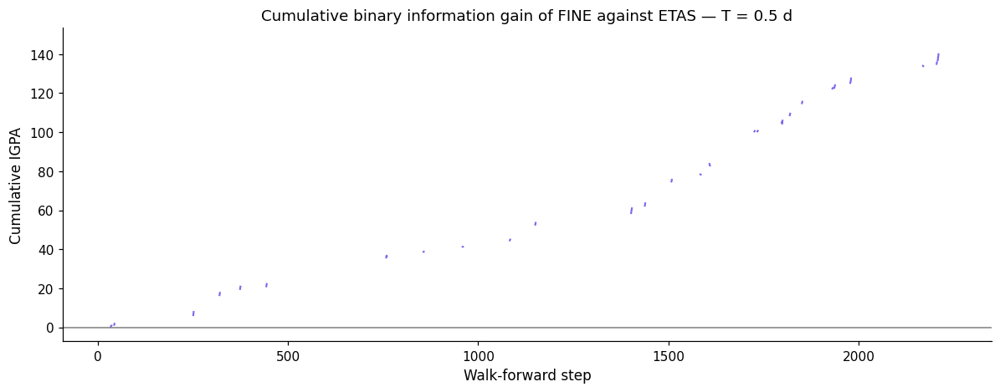

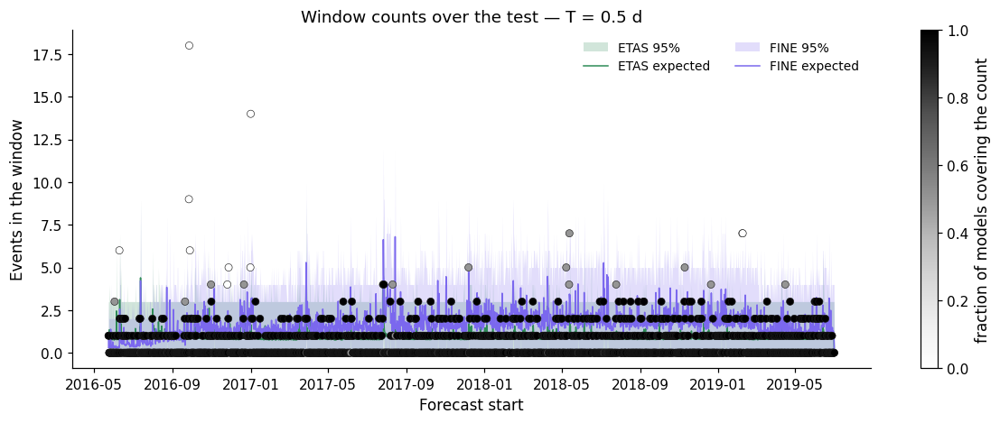

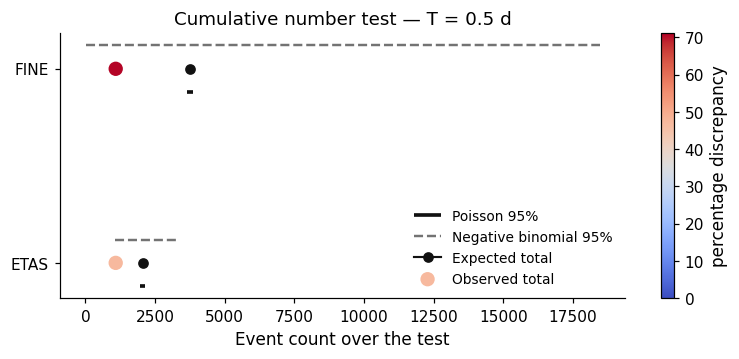

...

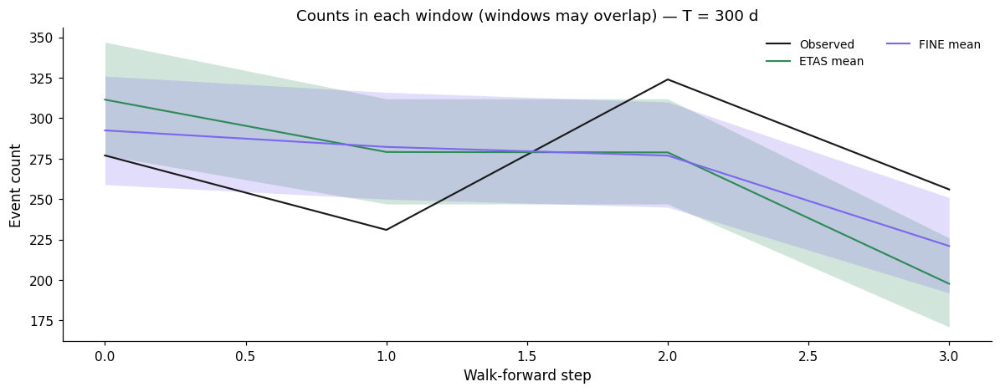

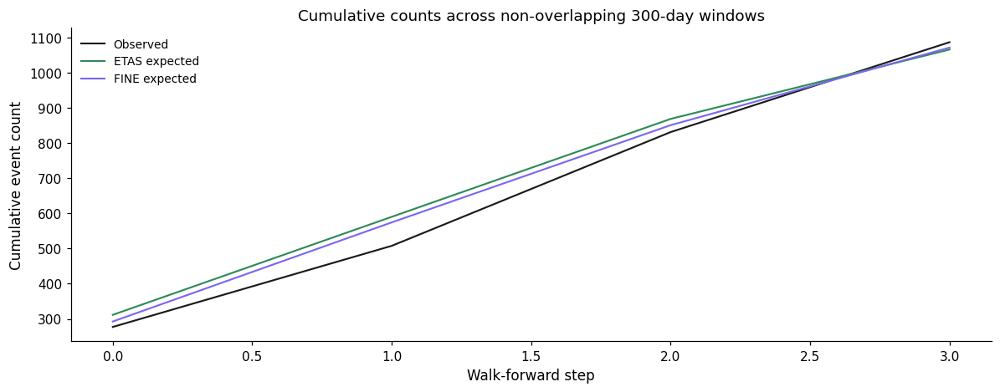

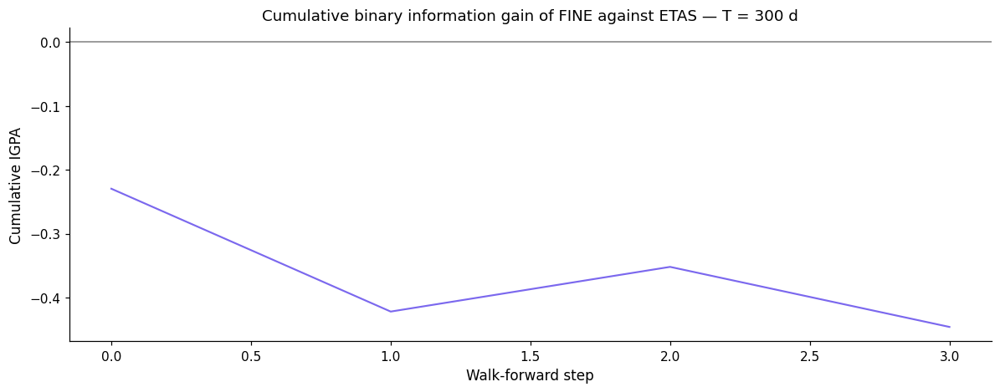

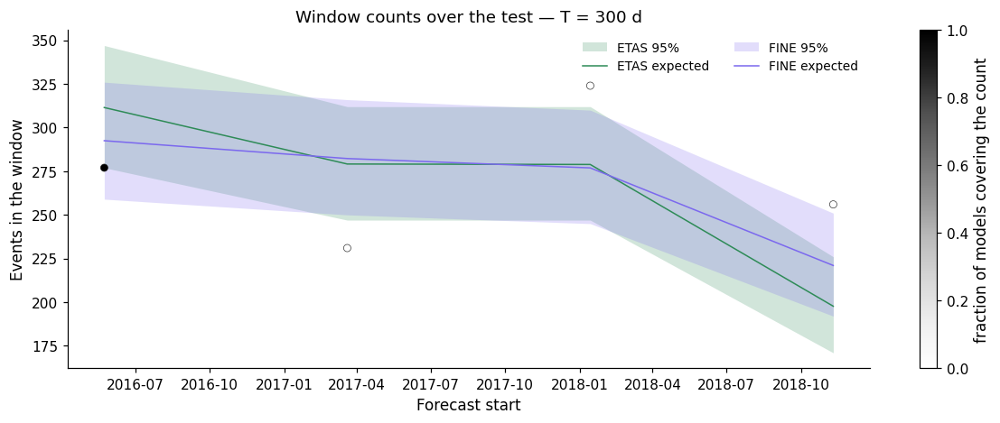

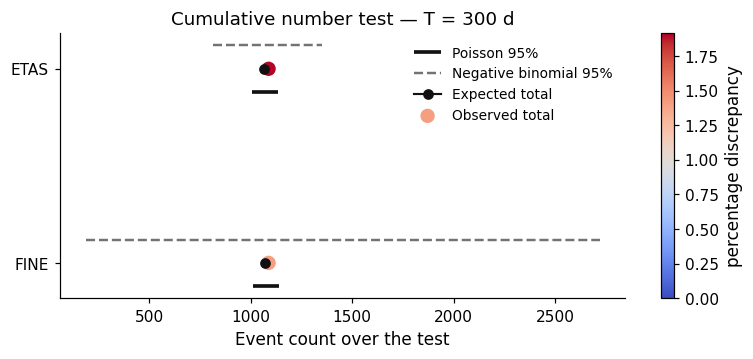

In [5]:
import importlib
importlib.reload(figures)
figures.configure(STYLE)

def scores_for(spec: dict) -> pd.DataFrame:
    frame = scores_all.loc[np.isclose(scores_all["horizon_days"], spec["horizon_days"])].copy()
    return frame


def realizations_for(spec: dict) -> pd.DataFrame:
    store = rolling_analysis.load_analysis(spec["horizon_dir"])
    return rolling_analysis.window_realization_counts(store, progress=print)


for spec in specs:
    tag = horizon_tag(spec["horizon_days"])
    horizon_scores = scores_for(spec)
    if horizon_scores.empty:
        continue
    export(figures.fig_walkforward_counts(horizon_scores, METHODS, spec["horizon_days"]), "counts_in_each_window", tag)
    if figures.windows_tile(horizon_scores):
        export(
            figures.fig_cumulative_counts(horizon_scores, spec["horizon_days"], METHODS),
            "cumulative_counts",
            tag,
        )
    export(figures.fig_cumulative_igpa(horizon_scores, spec["horizon_days"]), "cumulative_information_gain", tag)
    export(figures.fig_window_coverage(horizon_scores, METHODS, spec["horizon_days"]), "window_counts_over_the_test", tag)
    sub = cumulative_number.loc[np.isclose(cumulative_number["horizon_days"], spec["horizon_days"])]
    if len(sub):
        export(figures.fig_cumulative_number_rows(sub, spec["horizon_days"]), "cumulative_number_test", tag)


## Each horizon — count intervals, forecast skill, one window histogram

These use one row per simulated catalog (`analysis_cache/window_realization_counts.csv`). The table is written from the cached catalogs the first time it is missing.


realization counts cached: window_realization_counts.csv


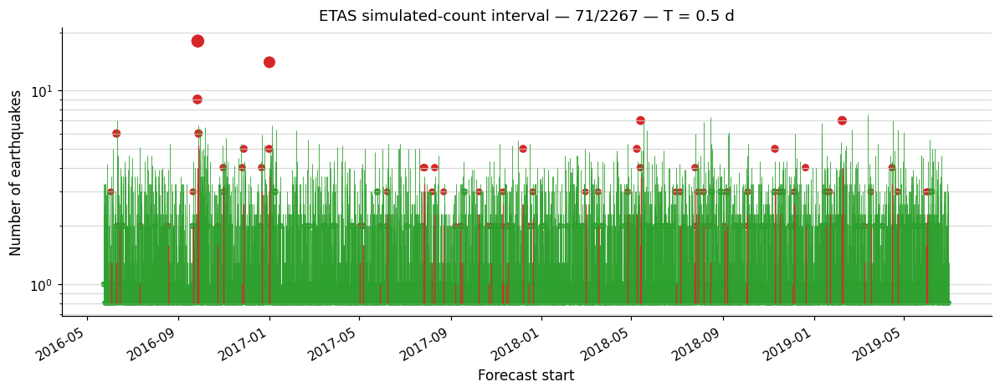

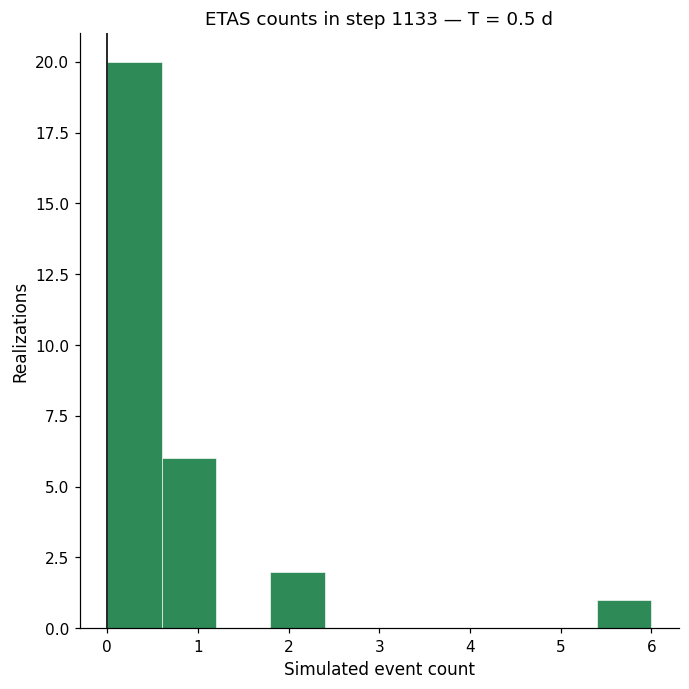

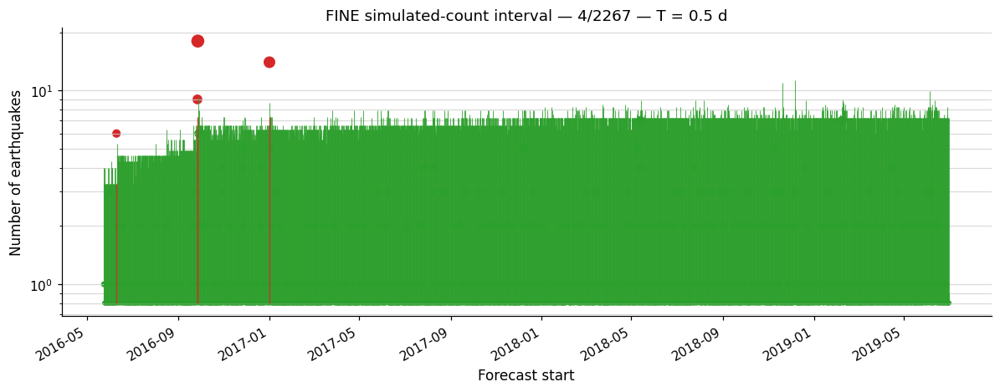

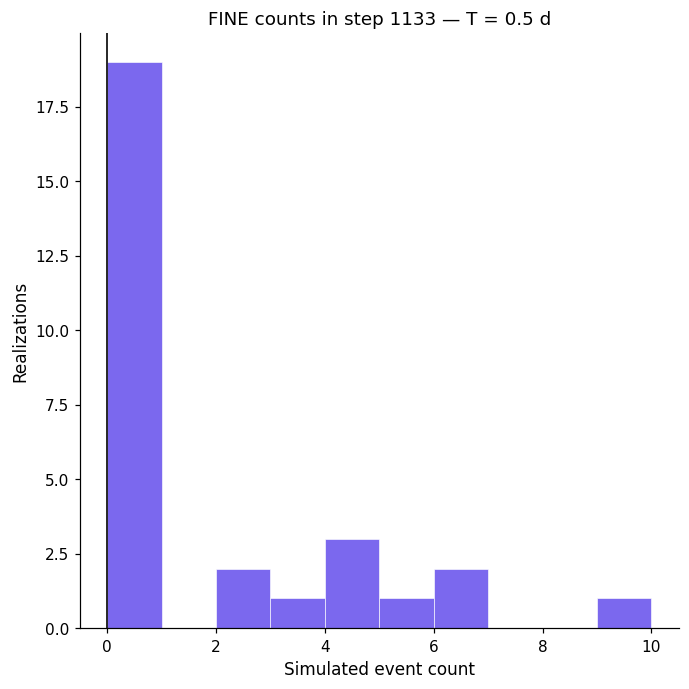

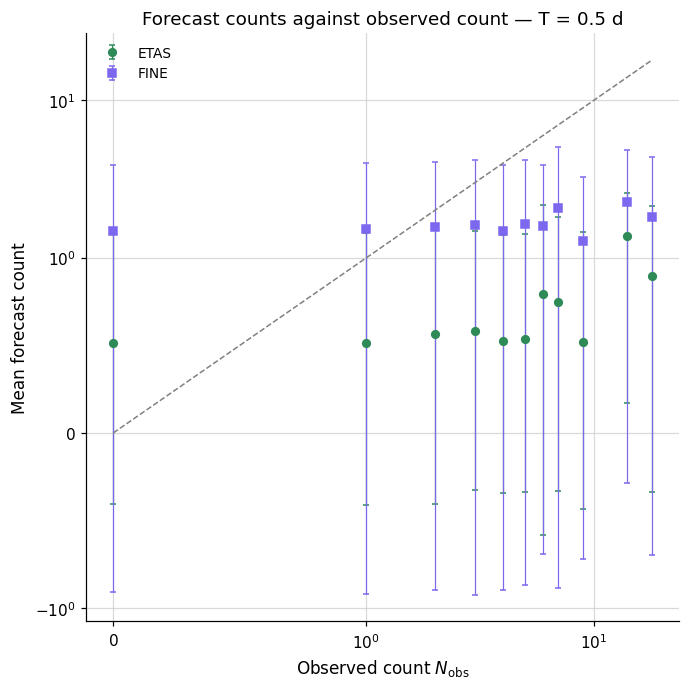

realization counts cached: window_realization_counts.csv


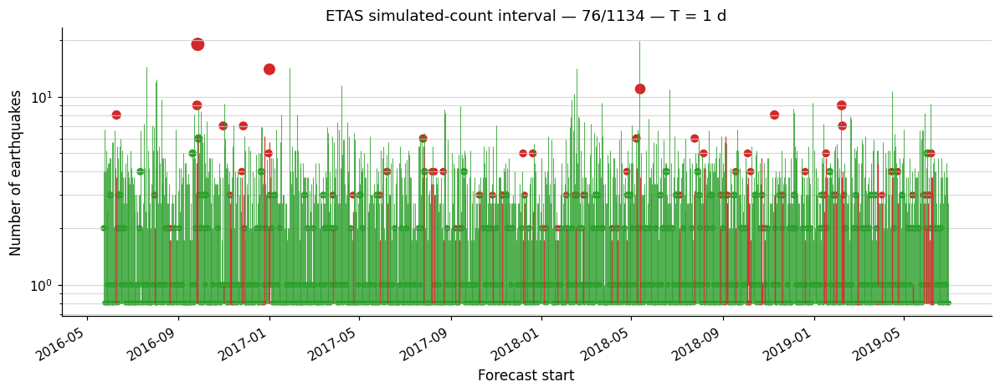

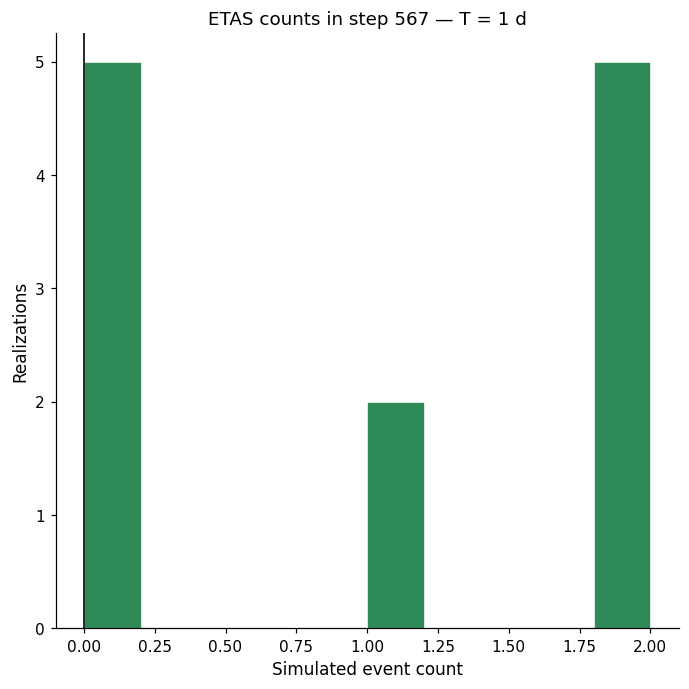

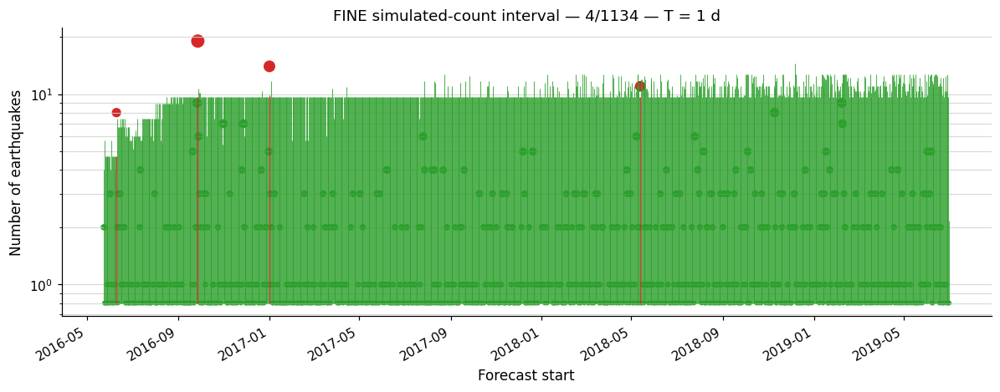

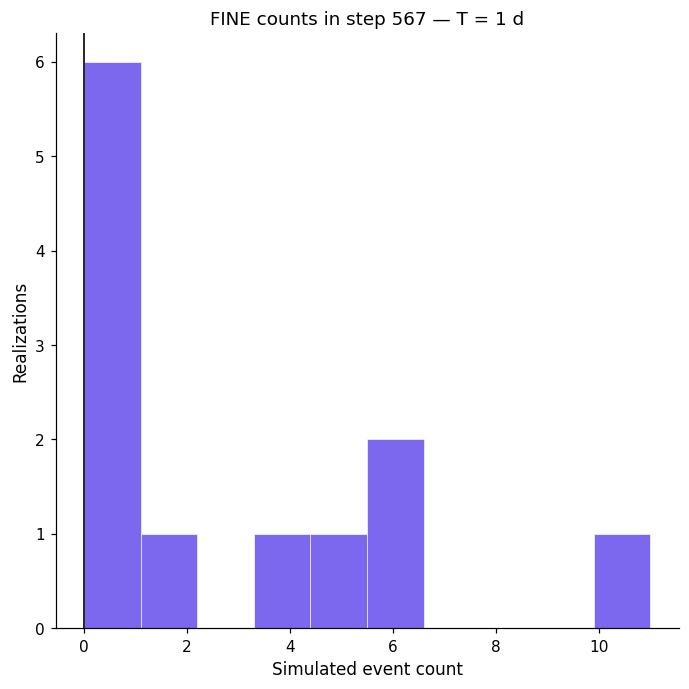

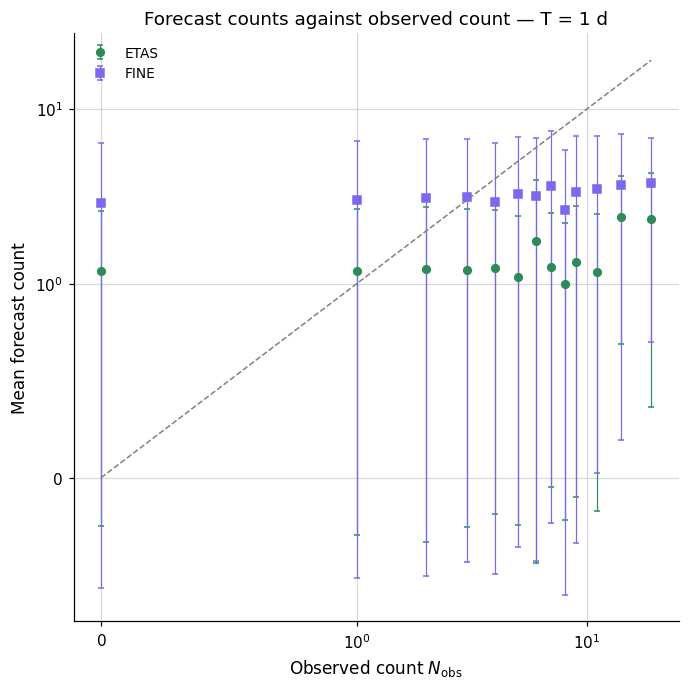

realization counts cached: window_realization_counts.csv


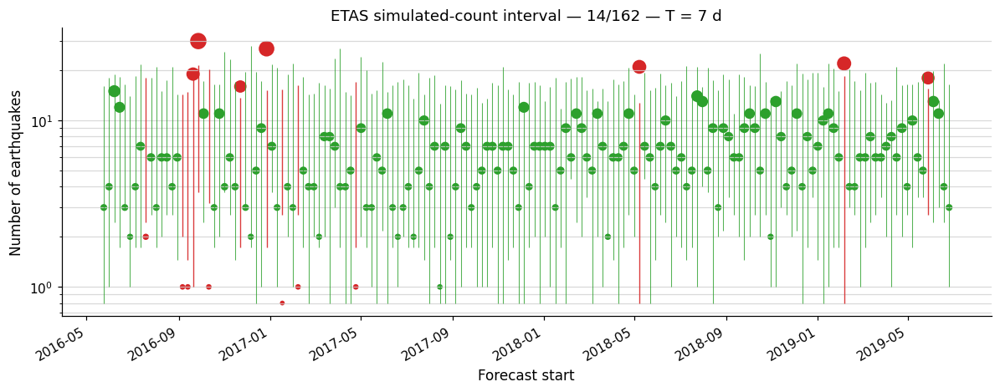

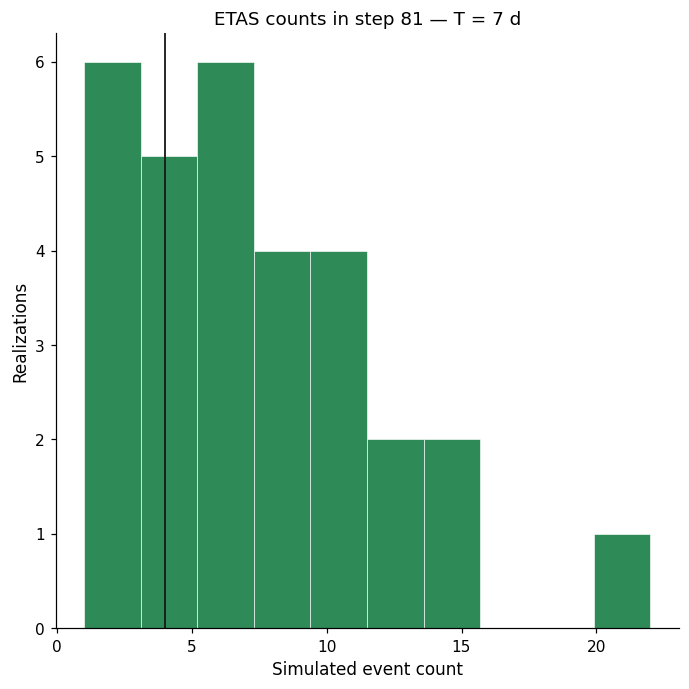

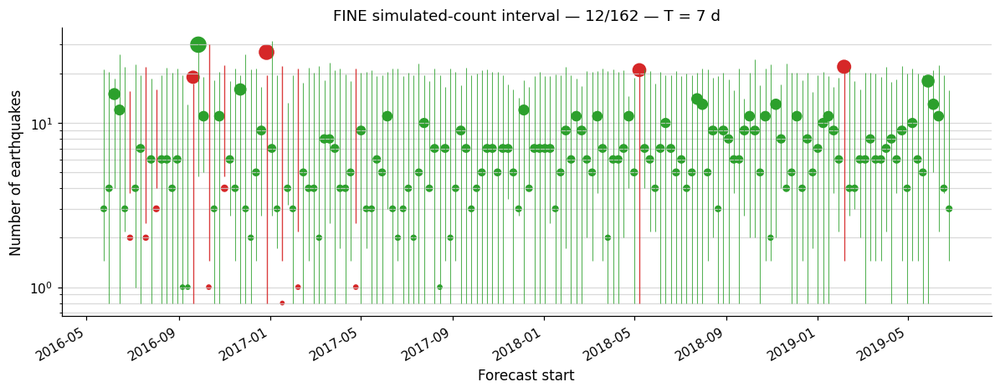

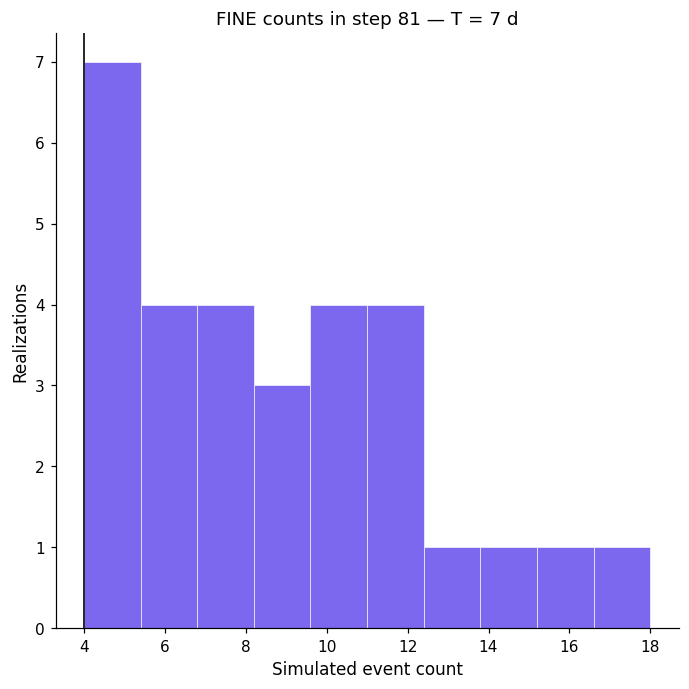

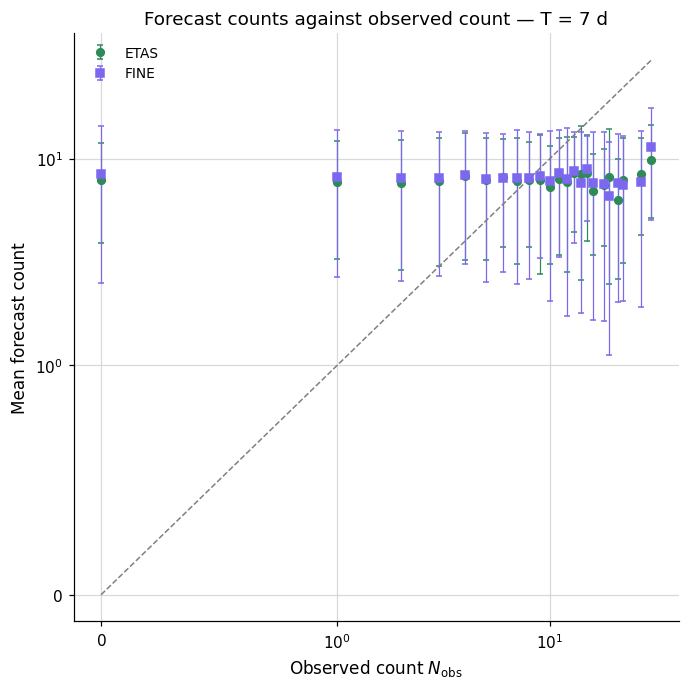

realization counts cached: window_realization_counts.csv


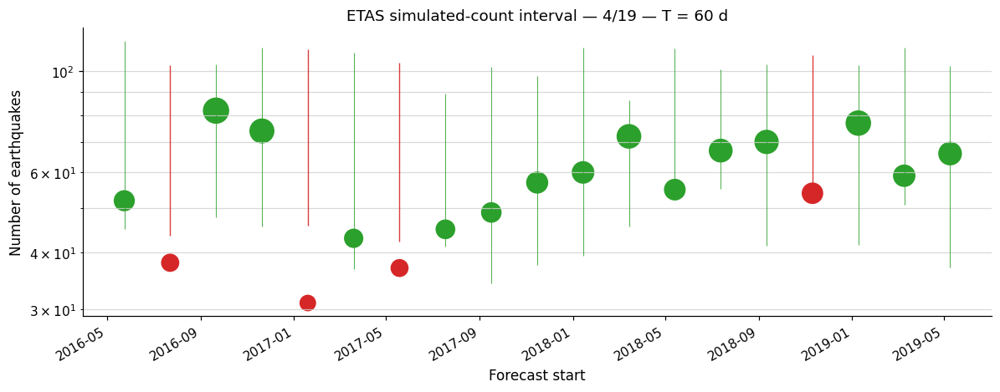

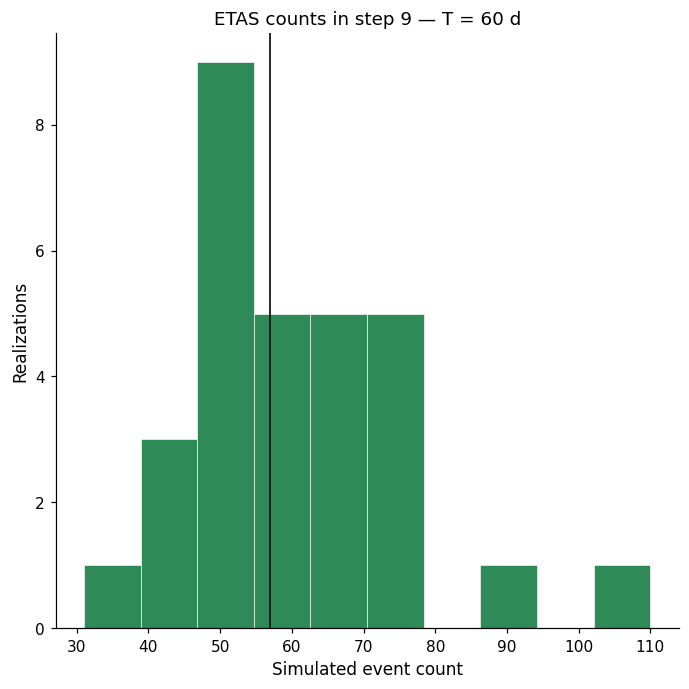

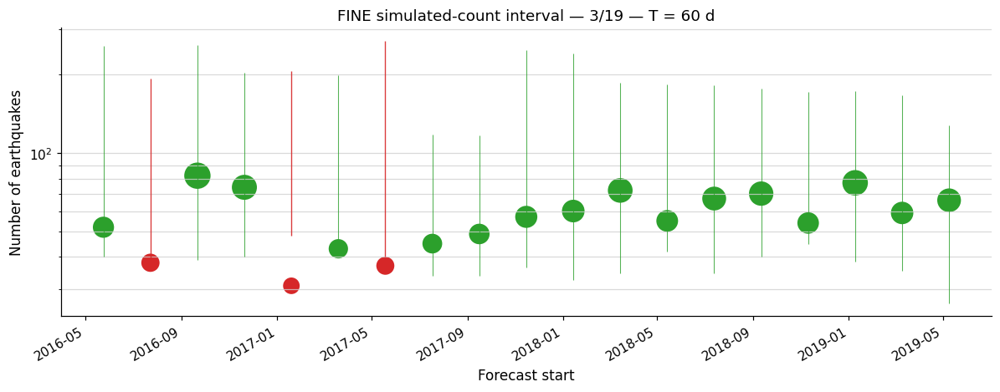

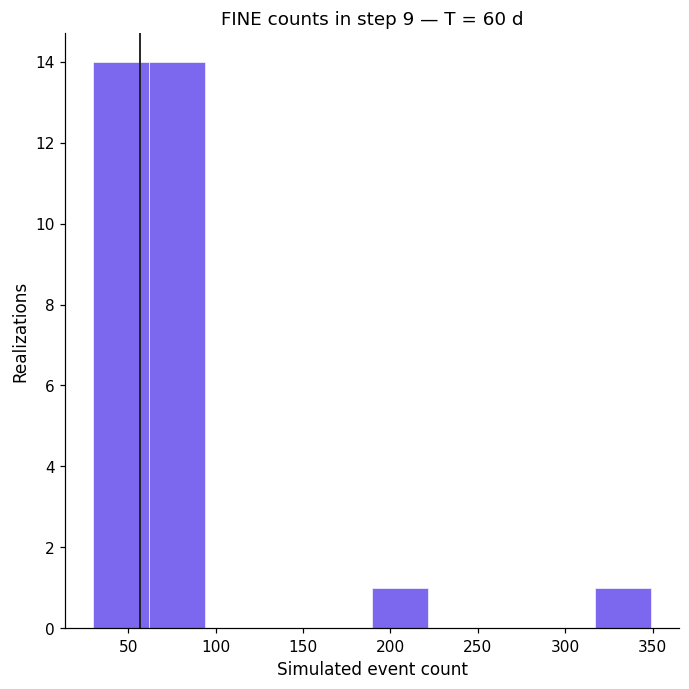

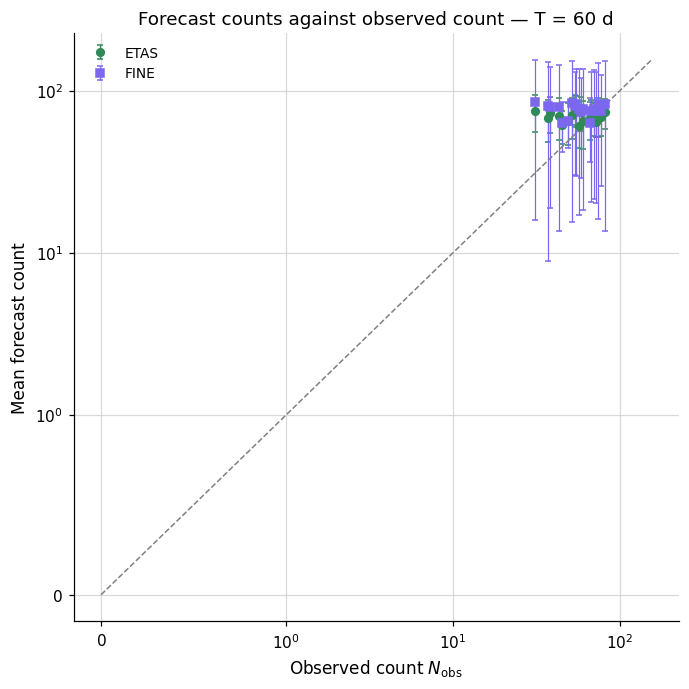

realization counts cached: window_realization_counts.csv


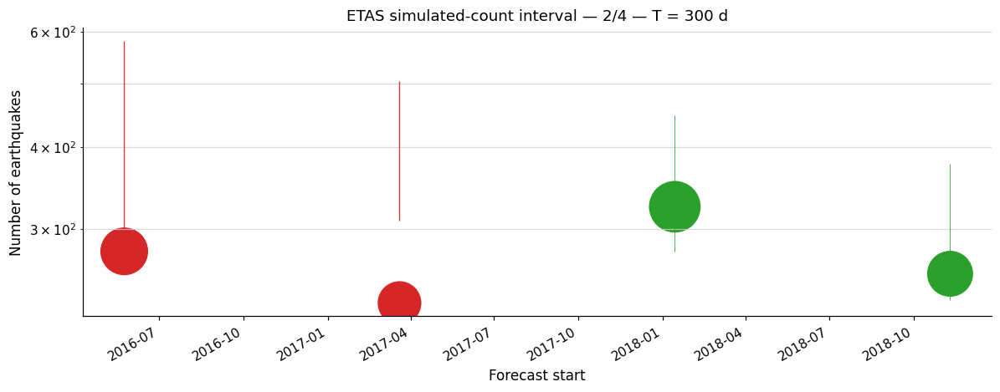

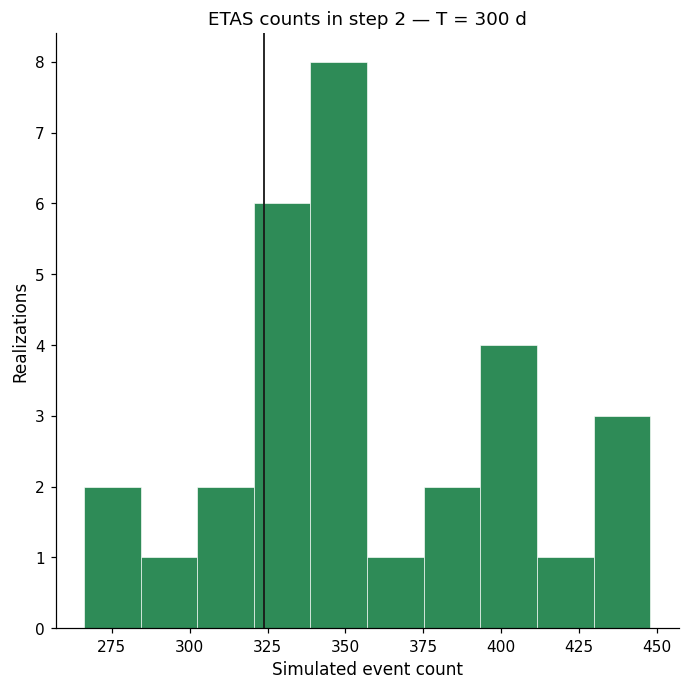

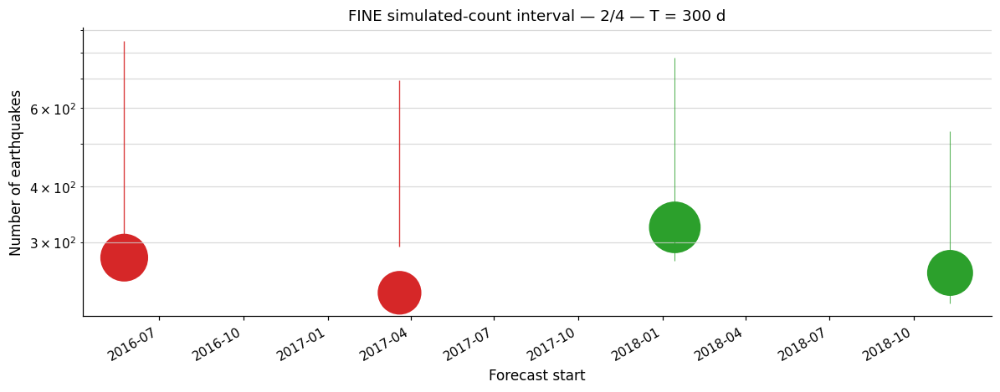

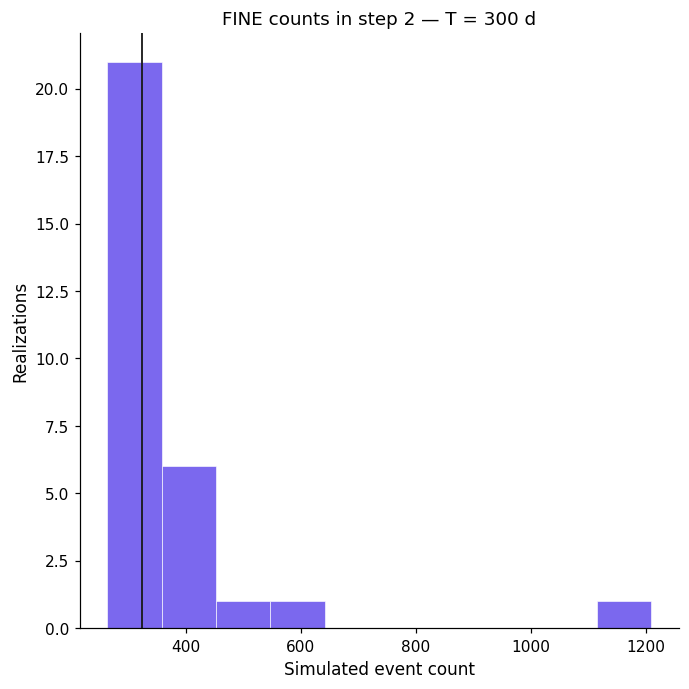

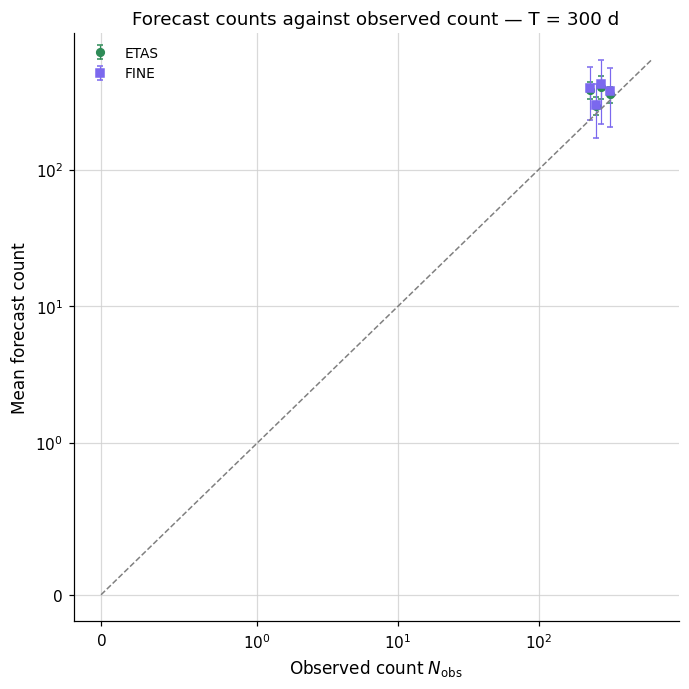

In [6]:
import importlib
importlib.reload(figures)
figures.configure(STYLE)

for spec in specs:
    tag = horizon_tag(spec["horizon_days"])
    realizations = realizations_for(spec)
    steps = np.sort(realizations["step_index"].unique())
    step = int(steps[len(steps) // 2]) if COUNT_HIST_STEP is None else int(COUNT_HIST_STEP)
    for method in METHODS:
        label = method.lower()
        export(
            figures.fig_simulated_count_interval(realizations, method, spec["horizon_days"]),
            f"{label}_simulated_count_interval",
            tag,
        )
        export(
            figures.fig_count_histogram(realizations, method, step, spec["horizon_days"]),
            f"{label}_counts_step_{step}",
            tag,
        )
    export(
        figures.fig_forecast_vs_observed(realizations, spec["horizon_days"], METHODS),
        "forecast_counts_against_observed",
        tag,
    )


## Each horizon — trajectory, rate, background, interevent, maps

Event catalogs and grids are loaded from the analysis cache. Spatial scatter, spatial histogram, and each rate map are separate files.


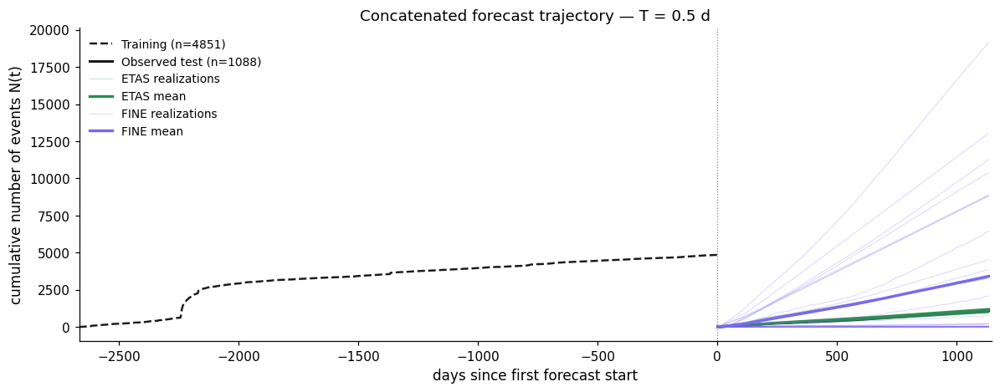

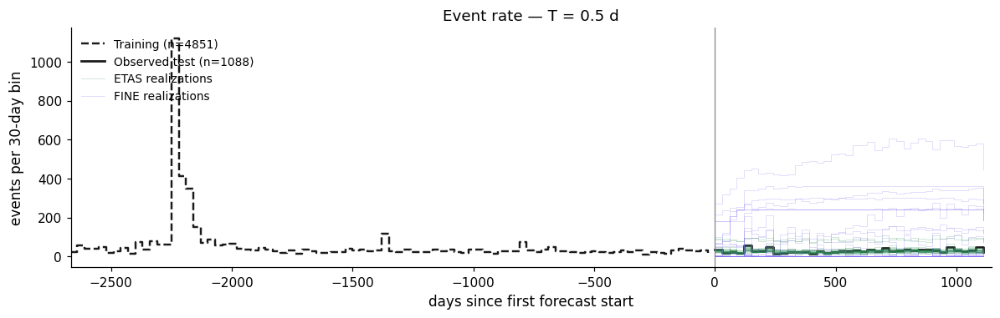

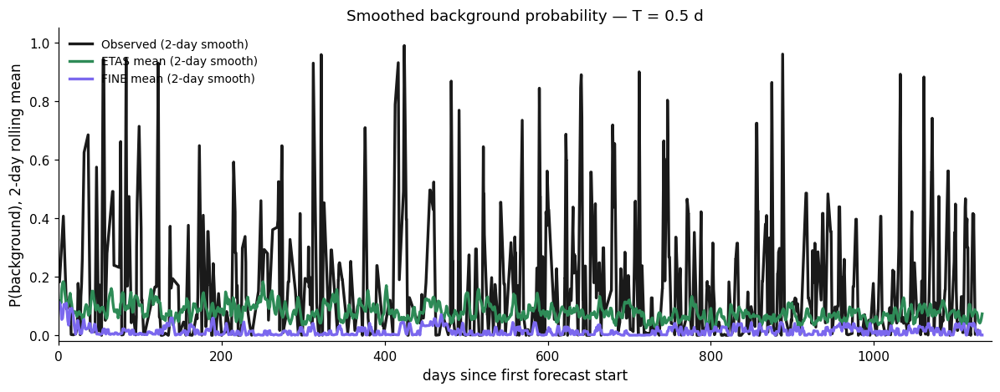

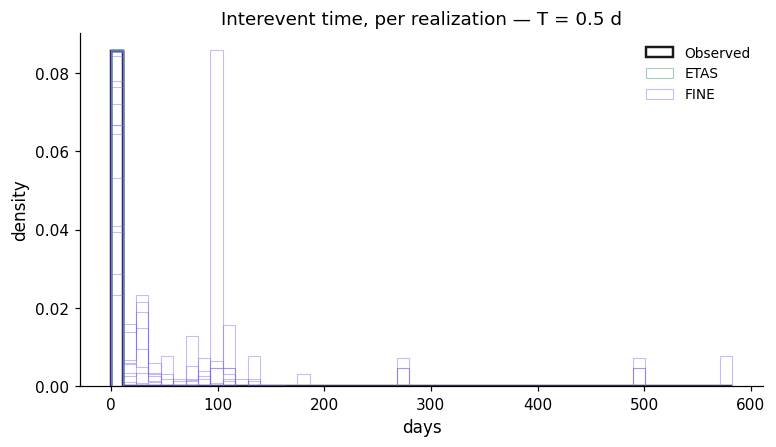

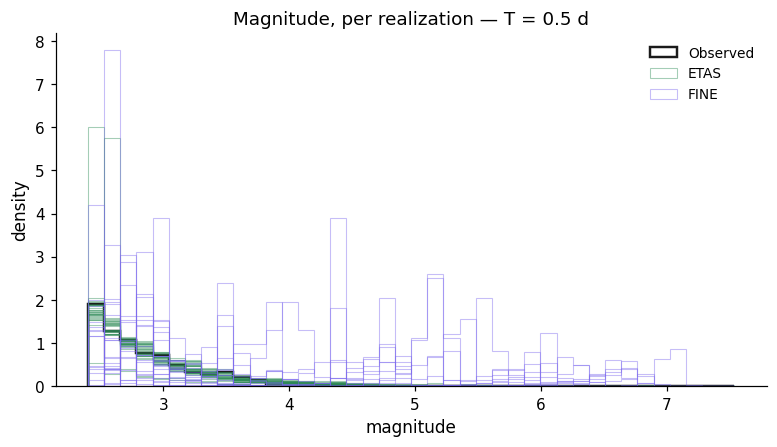

...

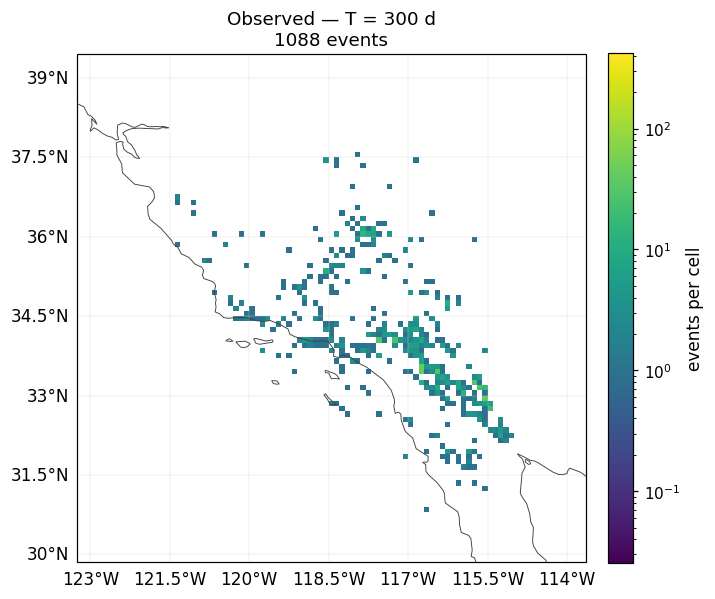

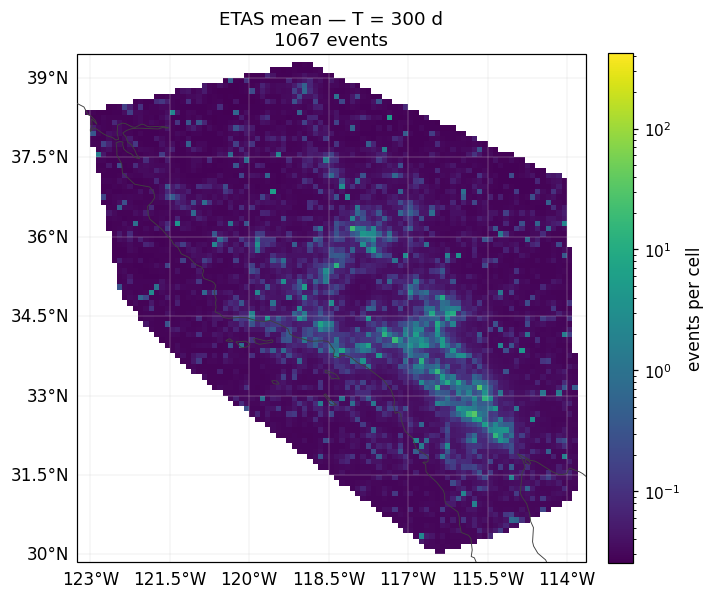

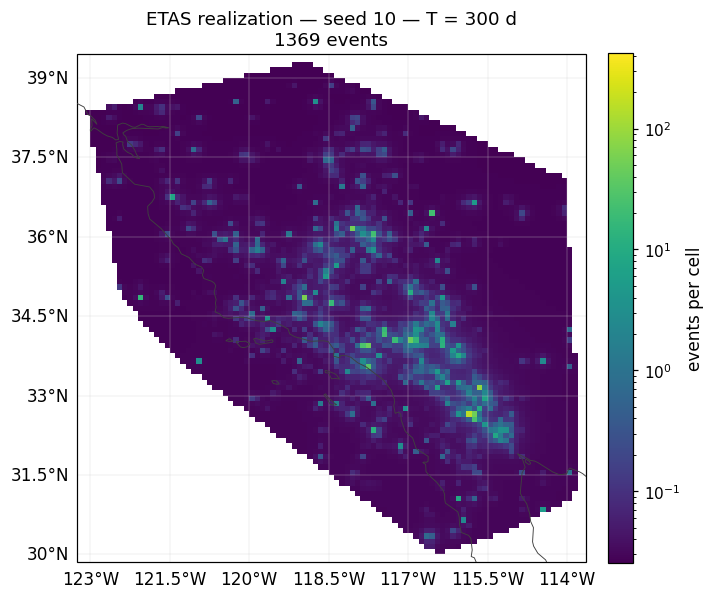

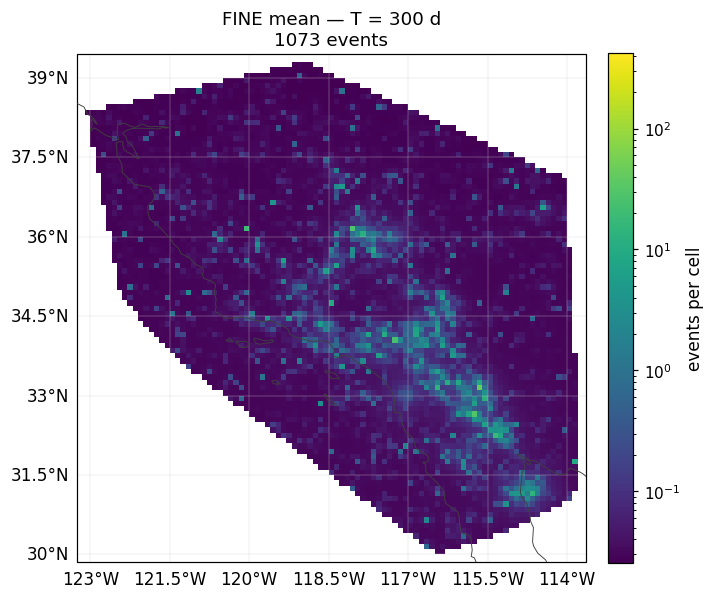

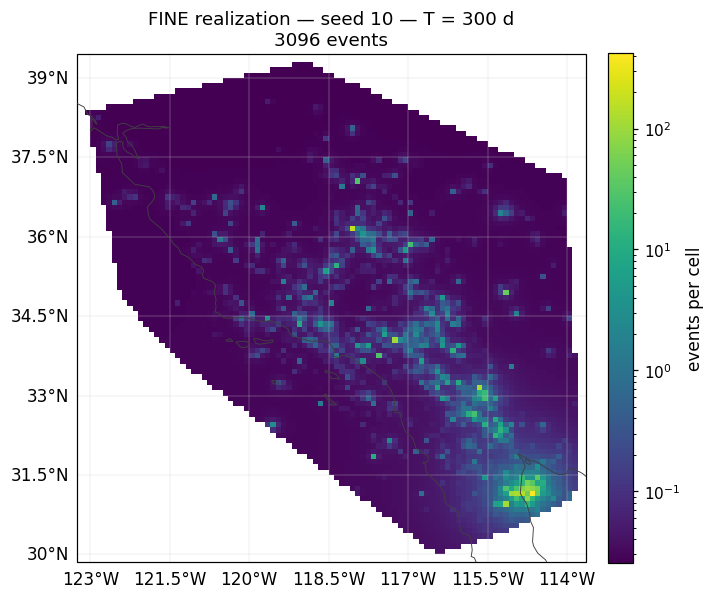

In [7]:
import importlib
importlib.reload(figures)
figures.configure(STYLE)

import etas.utility_functions as utility_functions

def _origin_days(origin: pd.Timestamp) -> float:
    return float((origin - figures.ORIGIN) / pd.Timedelta("1D"))


for spec in specs:
    tag = horizon_tag(spec["horizon_days"])
    days = spec["horizon_days"]
    store = rolling_analysis.load_analysis(spec["horizon_dir"])
    windows = store.windows()
    if windows.empty:
        continue
    origin = pd.Timestamp(windows["forecast_start"].min())
    origin_days = _origin_days(origin)
    observed = store.observed_frame()
    observed_days = observed["time_days"].to_numpy(dtype=float) - origin_days
    train = store.training_frame()
    train_days = train["time_days"].to_numpy(dtype=float) - origin_days
    forecast_end_days = float((windows["forecast_end"].max() - origin) / pd.Timedelta("1D"))
    seed_frames = {
        method: {int(seed): store.event_frame(method, int(seed)) for seed in store.seeds}
        for method in METHODS
    }
    export(
        figures.fig_trajectory(
            horizon_days=days,
            origin=origin,
            origin_days=origin_days,
            train_days=train_days,
            observed_days=observed_days,
            seed_frames=seed_frames,
            methods=METHODS,
            forecast_end_days=forecast_end_days,
        ),
        "concatenated_forecast_trajectory",
        tag,
    )
    export(
        figures.fig_event_rate(
            horizon_days=days,
            train_days=train_days,
            observed_days=observed_days,
            seed_frames=seed_frames,
            methods=METHODS,
            origin_days=origin_days,
            forecast_end_days=forecast_end_days,
            bin_days=EVENT_RATE_BIN_DAYS,
        ),
        "event_rate",
        tag,
    )
    background_path = store.cache_dir / "background_probability.csv"
    if background_path.is_file():
        background = pd.read_csv(background_path)
        smooth_days = max(days * 4.0, 1.0)
        export(
            figures.fig_smoothed_background(
                background,
                horizon_days=days,
                origin=origin,
                origin_days=origin_days,
                forecast_end_days=forecast_end_days,
                methods=METHODS,
                smooth_days=smooth_days,
            ),
            "smoothed_background_probability",
            tag,
        )

    test_iet = utility_functions.interevent_times(observed_days)
    test_mag = observed["magnitude"].to_numpy(dtype=float)
    iet_by_method = {}
    mag_by_method = {}
    for method in METHODS:
        iets = []
        mags = []
        for frame in seed_frames[method].values():
            rel = frame["time_days"].to_numpy(dtype=float) - origin_days
            iet = utility_functions.interevent_times(rel)
            mag = frame["magnitude"].to_numpy(dtype=float)
            if iet.size:
                iets.append(iet)
            if mag.size:
                mags.append(mag)
        iet_by_method[method] = iets
        mag_by_method[method] = mags
    iet_edges = figures._histogram_edges(list(iet_by_method.values()), test_iet, 50)
    mag_edges = figures._histogram_edges(list(mag_by_method.values()), test_mag, 40)
    export(
        figures.fig_distribution_per_realization(
            test_iet, iet_by_method, iet_edges, METHODS,
            title=f"Interevent time, per realization — T = {days:g} d", xlabel="days", horizon_days=days,
        ),
        "interevent_time_per_realization",
        tag,
    )
    export(
        figures.fig_distribution_per_realization(
            test_mag, mag_by_method, mag_edges, METHODS,
            title=f"Magnitude, per realization — T = {days:g} d", xlabel="magnitude", horizon_days=days,
        ),
        "magnitude_per_realization",
        tag,
    )

    obs_lon, obs_lat, obs_mag = store.observed_events()
    map_seed = int(store.seeds[0])
    pools = {}
    scatters = {}
    for method in METHODS:
        scatters[method] = store.events(method, map_seed)
        lon_p, lat_p, _mag = store.pooled_events(method, store.seeds)
        pools[method] = (lon_p, lat_p)
    all_lon = [obs_lon] + [pools[method][0] for method in METHODS]
    all_lat = [obs_lat] + [pools[method][1] for method in METHODS]
    lon_cat = np.concatenate([array for array in all_lon if array.size]) if any(array.size for array in all_lon) else np.array([])
    lat_cat = np.concatenate([array for array in all_lat if array.size]) if any(array.size for array in all_lat) else np.array([])
    if lon_cat.size:
        lon_pad = 0.05 * max(float(lon_cat.max() - lon_cat.min()), 0.5)
        lat_pad = 0.05 * max(float(lat_cat.max() - lat_cat.min()), 0.5)
        lon_range = (float(lon_cat.min()) - lon_pad, float(lon_cat.max()) + lon_pad)
        lat_range = (float(lat_cat.min()) - lat_pad, float(lat_cat.max()) + lat_pad)
        export(
            figures.fig_spatial_scatter(
                obs_lon, obs_lat, obs_mag,
                title=f"Observed test scatter (n={obs_lon.size})",
                color=STYLE["colors"]["observed"],
                horizon_days=days,
                lon_range=lon_range, lat_range=lat_range,
            ),
            "spatial_observed_scatter",
            tag,
        )
        export(
            figures.fig_spatial_hist(
                obs_lon, obs_lat,
                title=f"Observed test spatial histogram (n={obs_lon.size})",
                cmap=STYLE["cmaps"]["spatial_observed"],
                horizon_days=days,
                lon_range=lon_range, lat_range=lat_range,
            ),
            "spatial_observed_histogram",
            tag,
        )
        for method in METHODS:
            lon_s, lat_s, mag_s = scatters[method]
            export(
                figures.fig_spatial_scatter(
                    lon_s, lat_s, mag_s,
                    title=f"{figures.method_label(method)} scatter — seed {map_seed} (n={lon_s.size})",
                    color=figures.method_color(method),
                    horizon_days=days,
                    lon_range=lon_range, lat_range=lat_range,
                ),
                f"spatial_{method.lower()}_scatter",
                tag,
            )
            lon_p, lat_p = pools[method]
            export(
                figures.fig_spatial_hist(
                    lon_p, lat_p,
                    title=f"{figures.method_label(method)} spatial histogram — all seeds (n={lon_p.size})",
                    cmap=STYLE["cmaps"]["spatial_forecast"],
                    horizon_days=days,
                    lon_range=lon_range, lat_range=lat_range,
                ),
                f"spatial_{method.lower()}_histogram",
                tag,
            )

    origins = store.origins
    dh = store.dh
    pad = 0.15
    lon_edges = np.arange(origins[:, 0].min(), origins[:, 0].max() + dh * 1.01, dh)
    lat_edges = np.arange(origins[:, 1].min(), origins[:, 1].max() + dh * 1.01, dh)
    ix = np.rint((origins[:, 0] - lon_edges[0]) / dh).astype(int)
    iy = np.rint((origins[:, 1] - lat_edges[0]) / dh).astype(int)
    extent = [
        float(lon_edges[0]) - pad, float(lon_edges[-1]) + pad,
        float(lat_edges[0]) - pad, float(lat_edges[-1]) + pad,
    ]

    def _cell_image(values: np.ndarray) -> np.ndarray:
        image = np.full((lat_edges.size - 1, lon_edges.size - 1), np.nan)
        image[iy, ix] = np.asarray(values, dtype=float)
        return np.ma.masked_where(~np.isfinite(image) | (image <= 0), image)

    rate_panels = [
        ("observed", "Observed", store.observed_counts),
        ("etas_mean", f"{figures.method_label('etas')} mean", store.mean_spatial("etas")),
        ("etas_seed", f"{figures.method_label('etas')} realization — seed {map_seed}", store.seed_spatial("etas", map_seed)),
        ("fine_mean", f"{figures.method_label('FINE')} mean", store.mean_spatial("FINE")),
        ("fine_seed", f"{figures.method_label('FINE')} realization — seed {map_seed}", store.seed_spatial("FINE", map_seed)),
    ]
    norm = figures.shared_log_norm([values for _key, _title, values in rate_panels])
    for key, title, values in rate_panels:
        image = _cell_image(values)
        total = float(np.nansum(values))
        export(
            figures.fig_rate_map(
                lon_edges, lat_edges, image,
                title=f"{title}\n{total:.0f} events",
                norm=norm,
                horizon_days=days,
                extent=extent,
            ),
            f"rate_map_{key}",
            tag,
        )


## Each horizon — number, spatial, binary, and magnitude tests

The combined Stockman-style panels are split: interval, quantile series, magnitude timeline, and quantile histogram. Spatial and magnitude statistics are computed once and stored under each horizon's `analysis_cache/presentation_tables/`. Later runs only redraw.

S-test ζ and M-test κ across horizons are written in this section, because those quantiles are not in `scores.csv`. N-test δ and binary ζ across horizons are already in the earlier section.


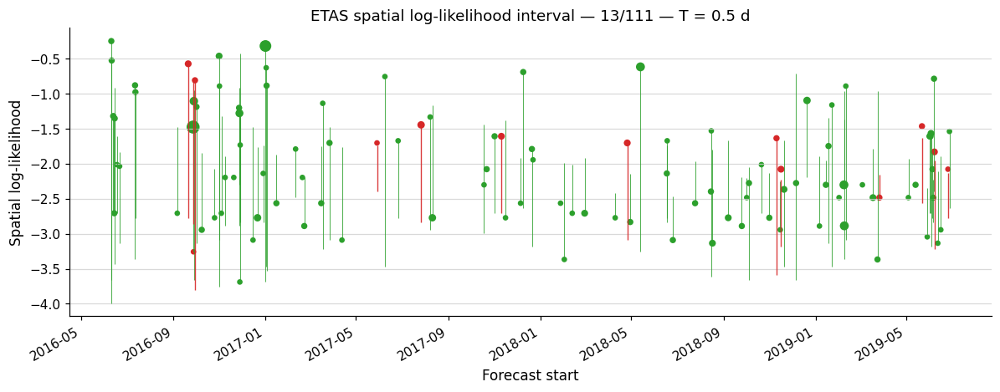

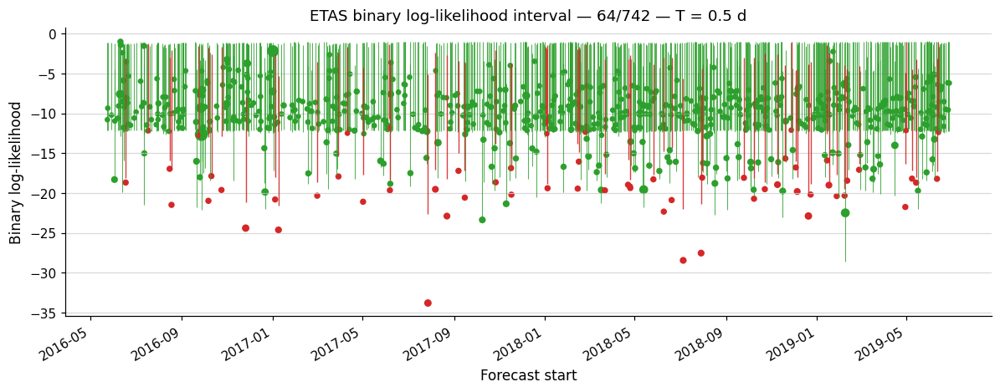

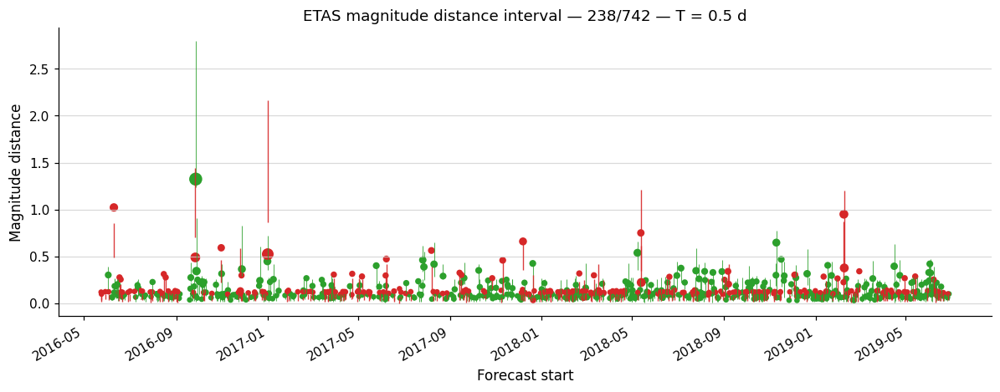

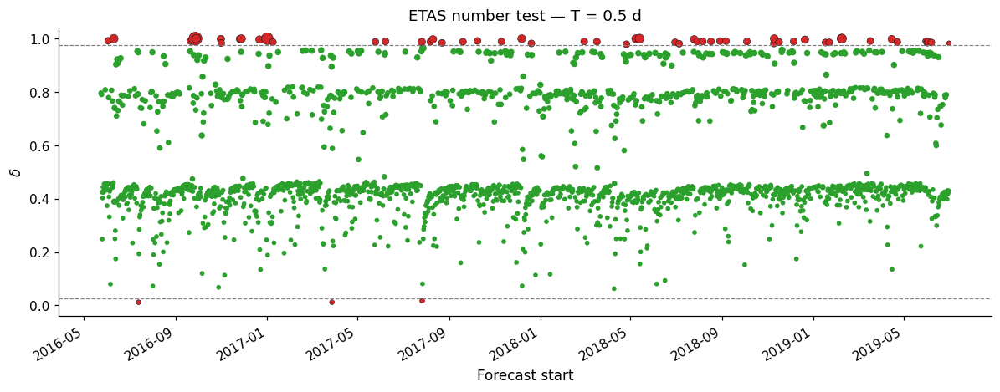

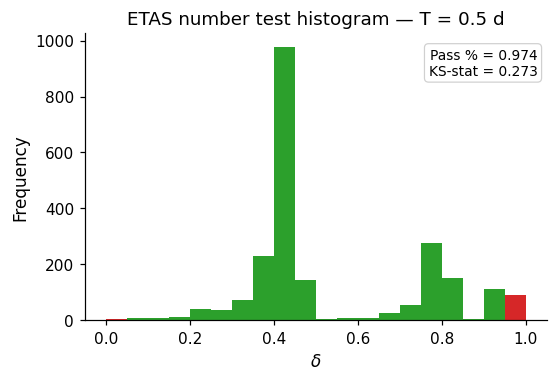

...

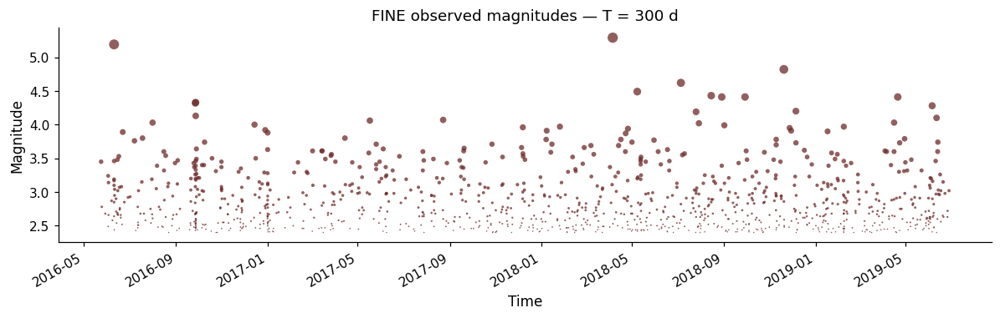

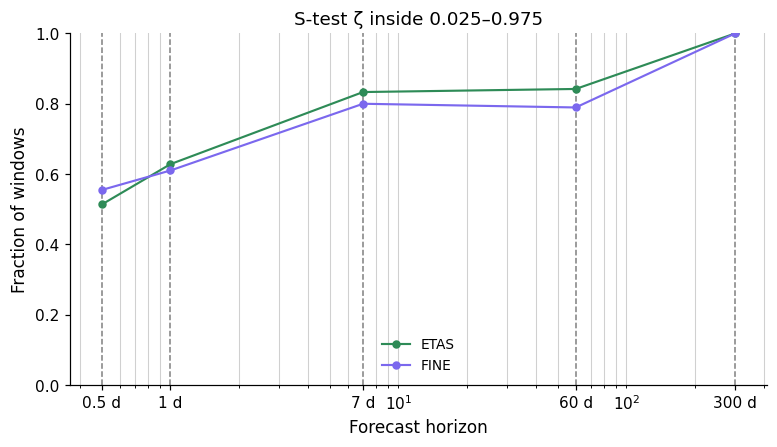

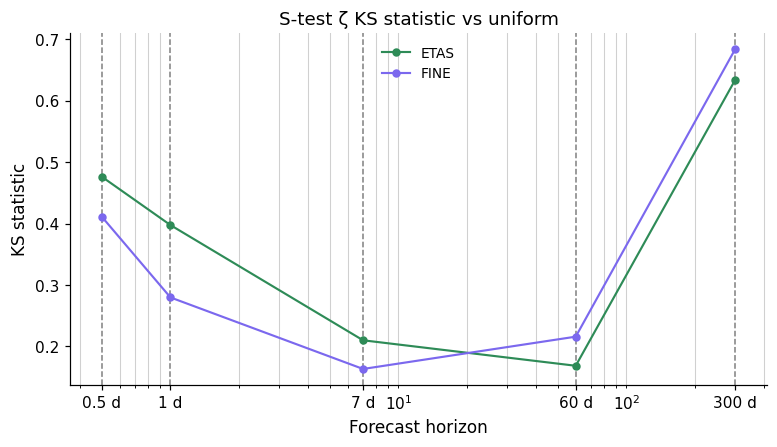

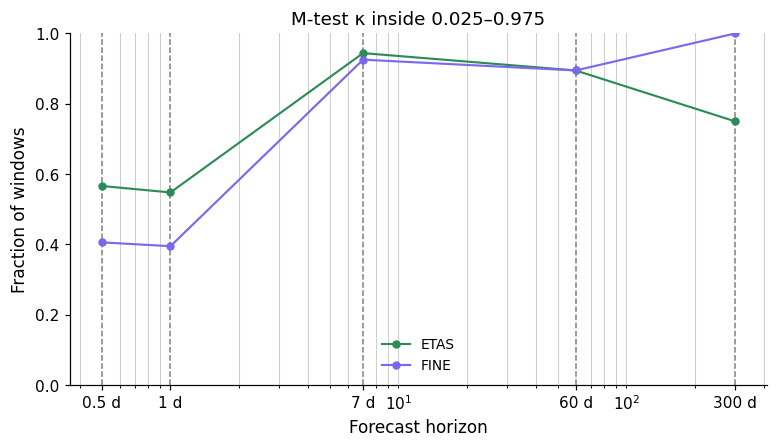

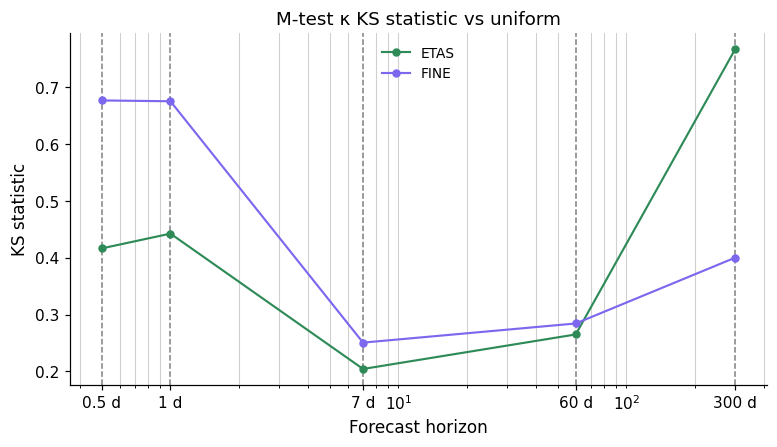

In [8]:
import importlib
importlib.reload(figures)
figures.configure(STYLE)

import hauksson_prerc_horizon_report as horizon_report

BAYONA_N_SIM = 200


def _read_table(path: Path) -> pd.DataFrame:
    frame = pd.read_csv(path)
    for column in ("forecast_start", "forecast_end", "time"):
        if column in frame.columns:
            frame[column] = pd.to_datetime(frame[column], format="mixed")
    return frame


def catalog_bundle(spec: dict) -> dict[str, pd.DataFrame]:
    cache = spec["horizon_dir"] / "analysis_cache" / "presentation_tables"
    cache.mkdir(parents=True, exist_ok=True)
    names = [
        "n_deltas",
        "m_deltas",
        "s_deltas",
        "observed_events",
        *[f"{method.lower()}_spatial_interval" for method in METHODS],
        *[f"{method.lower()}_magnitude_interval" for method in METHODS],
        *[f"{method.lower()}_binary_interval" for method in METHODS],
    ]
    paths = {name: cache / f"{name}.csv" for name in names}
    if (not REBUILD_CATALOG_TABLES) and all(path.is_file() for path in paths.values()):
        return {name: _read_table(path) for name, path in paths.items()}

    print(f"building catalog tables for {spec['horizon_days']:g} d", flush=True)
    store = rolling_analysis.load_analysis(spec["horizon_dir"])
    tables = horizon_report.prepare_tables(store)
    written = {
        "n_deltas": tables.n_deltas,
        "m_deltas": tables.m_deltas,
        "s_deltas": tables.s_deltas,
        "observed_events": tables.observed_events,
    }
    for method in METHODS:
        written[f"{method.lower()}_spatial_interval"] = horizon_report._statistic_interval(
            tables.s_realizations, method, "s_statistic", "s_observed",
        )
        written[f"{method.lower()}_magnitude_interval"] = horizon_report._statistic_interval(
            tables.m_realizations, method, "m_statistic", "m_observed",
        )
        print(f"  binary likelihood interval: {method}", flush=True)
        written[f"{method.lower()}_binary_interval"] = horizon_report.binary_interval_frame(
            tables, method, BAYONA_N_SIM,
        )
    for name, frame in written.items():
        frame.to_csv(paths[name], index=False)
    return {name: _read_table(path) for name, path in paths.items()}


zeta_rows = []
kappa_rows = []
for spec in specs:
    tag = horizon_tag(spec["horizon_days"])
    bundle = catalog_bundle(spec)
    events = bundle["observed_events"]
    for method in METHODS:
        label = method.lower()
        pretty = figures.method_label(method)
        export(
            figures.fig_statistic_interval(
                bundle[f"{label}_spatial_interval"],
                method,
                ylabel="Spatial log-likelihood",
                title=f"{pretty} spatial log-likelihood interval",
                horizon_days=spec["horizon_days"],
            ),
            f"{label}_spatial_log_likelihood_interval",
            tag,
        )
        export(
            figures.fig_statistic_interval(
                bundle[f"{label}_binary_interval"],
                method,
                ylabel="Binary log-likelihood",
                title=f"{pretty} binary log-likelihood interval",
                horizon_days=spec["horizon_days"],
            ),
            f"{label}_binary_log_likelihood_interval",
            tag,
        )
        export(
            figures.fig_statistic_interval(
                bundle[f"{label}_magnitude_interval"],
                method,
                ylabel="Magnitude distance",
                title=f"{pretty} magnitude distance interval",
                horizon_days=spec["horizon_days"],
            ),
            f"{label}_magnitude_distance_interval",
            tag,
        )
        pieces = [
            (bundle["n_deltas"], "delta", r"$\delta$", f"{pretty} number test"),
            (bundle["s_deltas"], "zeta", r"$\zeta$", f"{pretty} spatial test"),
            (bundle["s_deltas"], "binary_zeta", r"binary $\zeta$", f"{pretty} binary spatial test"),
            (bundle["m_deltas"], "kappa", r"$\kappa$", f"{pretty} magnitude test"),
        ]
        for frame, column, ylabel, title in pieces:
            slug = title.lower().replace(" ", "_")
            export(
                figures.fig_quantile_series(
                    frame, method, column, ylabel=ylabel, title=title,
                    horizon_days=spec["horizon_days"],
                ),
                f"{slug}_quantile",
                tag,
            )
            subset = frame.loc[frame["method"] == method, column]
            export(
                figures.fig_quantile_histogram(
                    subset.to_numpy(dtype=float),
                    title=f"{title} histogram",
                    xlabel=ylabel,
                    horizon_days=spec["horizon_days"],
                ),
                f"{slug}_histogram",
                tag,
            )
        if len(events) and "forecast_start" in bundle["n_deltas"].columns:
            subset = bundle["n_deltas"].loc[bundle["n_deltas"]["method"] == method]
            if len(subset) and "time" in events.columns and len(events):
                export(
                    figures.fig_magnitude_timeline(
                        events,
                        events["time"].min(),
                        events["time"].max(),
                        title=f"{pretty} observed magnitudes",
                        horizon_days=spec["horizon_days"],
                    ),
                    f"{label}_observed_magnitudes",
                    tag,
                )
        for column, key in (("zeta", "zeta"), ("kappa", "kappa")):
            source = bundle["s_deltas"] if column == "zeta" else bundle["m_deltas"]
            values = source.loc[source["method"] == method, column]
            row = {
                "horizon_days": spec["horizon_days"],
                "method": method,
                f"fraction_{key}_inside_band": _band_fraction(values),
                f"ks_{key}": _ks_uniform(values),
            }
            (zeta_rows if column == "zeta" else kappa_rows).append(row)

if zeta_rows:
    zeta_band = pd.DataFrame(zeta_rows)
    for metric, title, ylabel, ylim in (
        ("fraction_zeta_inside_band", "S-test ζ inside 0.025–0.975", "Fraction of windows", (0.0, 1.0)),
        ("ks_zeta", "S-test ζ KS statistic vs uniform", "KS statistic", None),
    ):
        export(
            figures.fig_metric_vs_horizon(
                zeta_band, metric, HORIZON_LIST,
                title=title, ylabel=ylabel, methods=METHODS, ylim=ylim,
            ),
            metric,
            "across_horizons",
        )
if kappa_rows:
    kappa_band = pd.DataFrame(kappa_rows)
    for metric, title, ylabel, ylim in (
        ("fraction_kappa_inside_band", "M-test κ inside 0.025–0.975", "Fraction of windows", (0.0, 1.0)),
        ("ks_kappa", "M-test κ KS statistic vs uniform", "KS statistic", None),
    ):
        export(
            figures.fig_metric_vs_horizon(
                kappa_band, metric, HORIZON_LIST,
                title=title, ylabel=ylabel, methods=METHODS, ylim=ylim,
            ),
            metric,
            "across_horizons",
        )


## Combined methods

ETAS keeps the green and red markers. FINE uses the secondary colors: blue inside the 0.025–0.975 band, gold outside it. Set `COMBINED_HORIZON` and `COMBINED_METRIC`, then re-run this cell.

`delta` is the number-test δ. `zeta` is the spatial-test ζ. `binary_zeta` is the binary spatial test. `kappa` is the magnitude-test κ.

The histogram uses the same split: ETAS is a translucent fill, FINE is the outline.


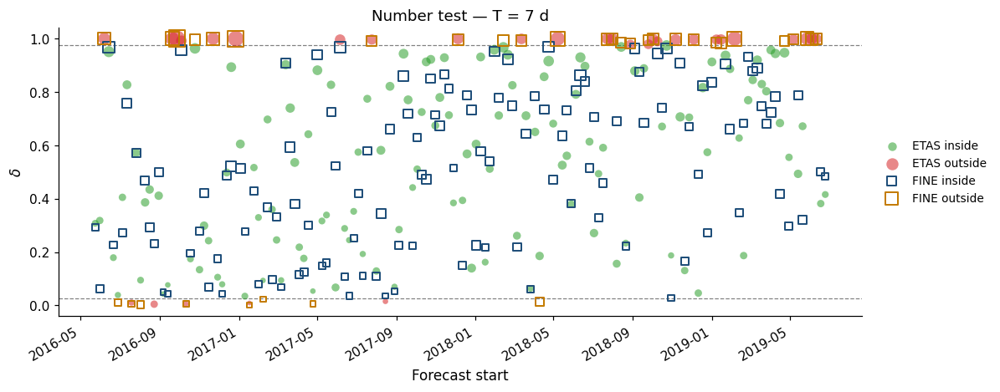

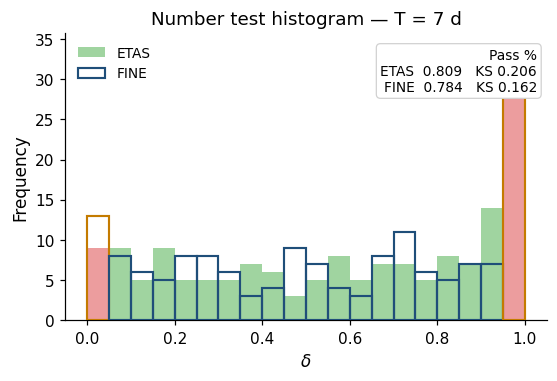

In [9]:
import importlib
importlib.reload(figures)

# Change these, then re-run this cell.
COMBINED_HORIZON = 7.0
COMBINED_METRIC = "delta"  # delta | zeta | binary_zeta | kappa

COMBINED_METRICS = {
    "delta": ("n_deltas", r"$\delta$", "Number test"),
    "zeta": ("s_deltas", r"$\zeta$", "Spatial test"),
    "binary_zeta": ("s_deltas", r"binary $\zeta$", "Binary spatial test"),
    "kappa": ("m_deltas", r"$\kappa$", "Magnitude test"),
}

figures.configure(STYLE)
table_name, ylabel, title = COMBINED_METRICS[COMBINED_METRIC]
chosen = [spec for spec in specs if np.isclose(spec["horizon_days"], float(COMBINED_HORIZON))]
if not chosen:
    available = ", ".join(f"{item['horizon_days']:g} d" for item in specs)
    display(Markdown(f"*No cached horizon at T = {COMBINED_HORIZON:g} d. Available: {available}.*"))
else:
    bundle = catalog_bundle(chosen[0])
    export(
        figures.fig_quantile_series_combined(
            bundle[table_name],
            METHODS,
            COMBINED_METRIC,
            ylabel=ylabel,
            title=title,
            horizon_days=float(COMBINED_HORIZON),
        ),
        f"combined_{COMBINED_METRIC}",
        horizon_tag(float(COMBINED_HORIZON)),
    )
    export(
        figures.fig_quantile_histogram_combined(
            bundle[table_name],
            METHODS,
            COMBINED_METRIC,
            xlabel=ylabel,
            title=title,
            horizon_days=float(COMBINED_HORIZON),
        ),
        f"combined_{COMBINED_METRIC}_histogram",
        horizon_tag(float(COMBINED_HORIZON)),
    )


## Spatial and binary ζ

The same two combined figures, for the spatial-test ζ and the binary spatial ζ. The horizon is `COMBINED_HORIZON` from the cell above.


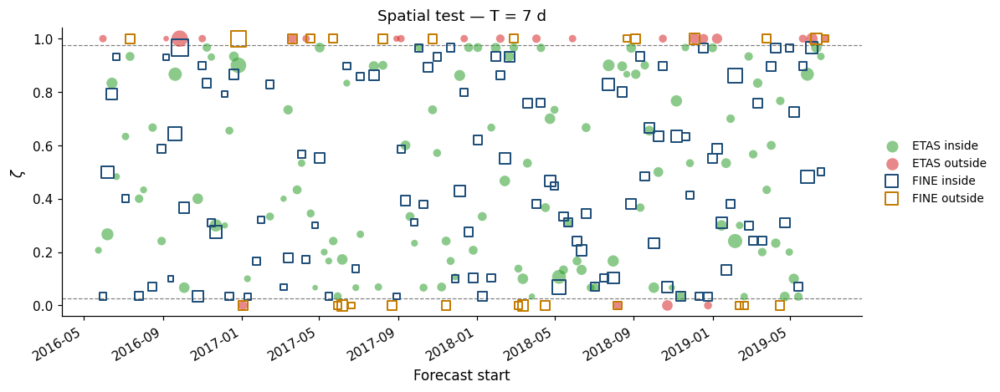

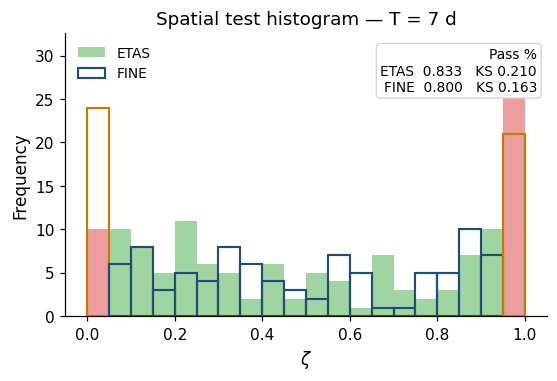

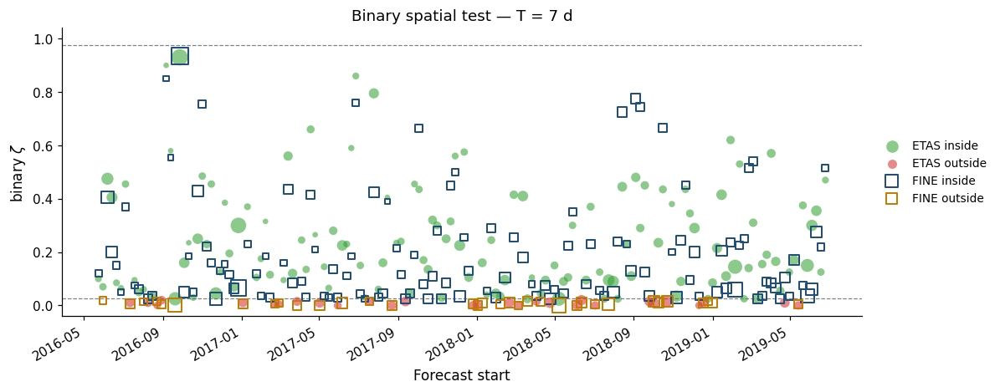

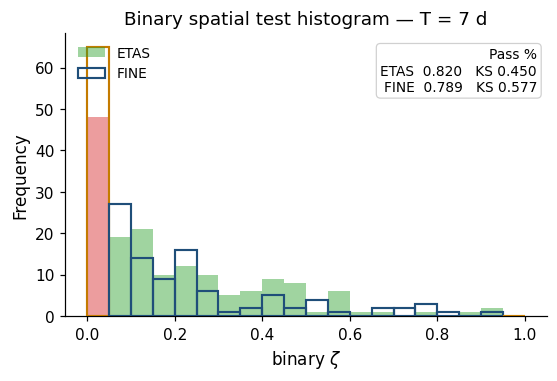

In [10]:
import importlib
importlib.reload(figures)
figures.configure(STYLE)

SPATIAL_HORIZON = float(COMBINED_HORIZON)
SPATIAL_METRICS = {
    "zeta": ("s_deltas", r"$\zeta$", "Spatial test"),
    "binary_zeta": ("s_deltas", r"binary $\zeta$", "Binary spatial test"),
}

chosen = [spec for spec in specs if np.isclose(spec["horizon_days"], SPATIAL_HORIZON)]
if not chosen:
    available = ", ".join(f"{item['horizon_days']:g} d" for item in specs)
    display(Markdown(f"*No cached horizon at T = {SPATIAL_HORIZON:g} d. Available: {available}.*"))
else:
    bundle = catalog_bundle(chosen[0])
    for metric, (table_name, ylabel, title) in SPATIAL_METRICS.items():
        export(
            figures.fig_quantile_series_combined(
                bundle[table_name],
                METHODS,
                metric,
                ylabel=ylabel,
                title=title,
                horizon_days=SPATIAL_HORIZON,
            ),
            f"combined_{metric}",
            horizon_tag(SPATIAL_HORIZON),
        )
        export(
            figures.fig_quantile_histogram_combined(
                bundle[table_name],
                METHODS,
                metric,
                xlabel=ylabel,
                title=title,
                horizon_days=SPATIAL_HORIZON,
            ),
            f"combined_{metric}_histogram",
            horizon_tag(SPATIAL_HORIZON),
        )
